In [ ]:
import os
import gc
import json
import shutil
import random
import pickle
import torch
import torchaudio
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torchaudio.transforms as ta_transforms
from torch.utils.data import Dataset, DataLoader
from torchaudio.models import HDemucs
from torchaudio.pipelines import HDEMUCS_HIGH_MUSDB

# =============================================================================
# 1. HARDWARE & KAGGLE SETUP
# =============================================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n{'='*52}")
print(f"🖥️  HARDWARE: {DEVICE.type.upper()} ACTIVE")
if DEVICE.type == 'cuda':
    print(f"    GPU  : {torch.cuda.get_device_name(0)}")
    print(f"    VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"{'='*52}")

os.makedirs("/root/.config/kaggle", exist_ok=True)
creds = {"username": "surya5510", "key": "KGAT_680693999b61b942df6967cf0ef695e3"}
with open("/root/.config/kaggle/kaggle.json", "w") as f:
    json.dump(creds, f)
os.chmod("/root/.config/kaggle/kaggle.json", 0o600)

# ── STARTUP PUSH TEST ─────────────────────────────────────────────────────────
print("\n🔌 Testing Kaggle push connection...")
os.system("pip install --upgrade kaggle -q")

import subprocess
r = subprocess.run(["kaggle", "config", "view"], capture_output=True, text=True)
print(f"  Config : {r.stdout.strip()}")

_test_staging = "/kaggle/working/push_test"
os.makedirs(_test_staging, exist_ok=True)
with open(os.path.join(_test_staging, "heartbeat.txt"), "w") as f:
    f.write("push test ok")
_test_meta = {"title": "lastttmodel", "id": "surya5510/lastttmodel",
              "licenses": [{"name": "CC0-1.0"}]}
with open(os.path.join(_test_staging, "dataset-metadata.json"), "w") as f:
    json.dump(_test_meta, f)
_ret = os.system(
    f"kaggle datasets version -p {_test_staging} -m 'Startup heartbeat' --dir-mode zip"
)
if _ret == 0:
    print("  ✅ PUSH TEST PASSED — auto-push is working")
else:
    print(f"  ❌ PUSH TEST FAILED (code {_ret}) — fix before training")
    print("     Check: did you create surya5510/lastttmodel on Kaggle?")
    print("     And add it as an INPUT dataset in this notebook?")
print("─"*52)

# ── Names & Paths ─────────────────────────────────────────────────────────────
KAGGLE_USERNAME  = "surya5510"
SRC_USERNAME     = "surya5510"

NEW_DATASET_NAME = "lastttmodel"
DATASET_SLUG     = f"{KAGGLE_USERNAME}/{NEW_DATASET_NAME}"
FILENAME         = "sonic_4stem.pth"
BEST_FILENAME    = "sonic_4stem_best.pth"

STAGING_DIR      = "/kaggle/working/ckpt_staging"
WORKING_PATH     = f"/kaggle/working/{FILENAME}"
BEST_PATH        = f"/kaggle/working/{BEST_FILENAME}"

PERSISTENT_PATH  = f"/kaggle/input/datasets/{KAGGLE_USERNAME}/{NEW_DATASET_NAME}/{FILENAME}"
PERSISTENT_BEST  = f"/kaggle/input/datasets/{KAGGLE_USERNAME}/{NEW_DATASET_NAME}/{BEST_FILENAME}"

SOURCE_CKPT_PATH    = "/kaggle/input/datasets/surya5510/lastttmodel/4stemLasttttttt.pth"
OLD_PERSISTENT_PATH = f"/kaggle/input/datasets/suryamanoharan33/hdemucs4stem55/{FILENAME}"
OLD_PERSISTENT_BEST = f"/kaggle/input/datasets/suryamanoharan33/hdemucs4stem55/{BEST_FILENAME}"

SIXSTEM_DATASET  = "pretrainedhdemucs55"
SIXSTEM_BEST     = (f"/kaggle/input/datasets/{SRC_USERNAME}/"
                    f"{SIXSTEM_DATASET}/sonic_separator_pretrained_best.pth")

PKL_PATH = f"/kaggle/input/datasets/{SRC_USERNAME}/6stem-split/6stem_splits.pkl"


def push_to_dataset():
    """Push latest + best checkpoints to lastttmodel on Kaggle."""
    try:
        os.makedirs(STAGING_DIR, exist_ok=True)
        if os.path.exists(WORKING_PATH):
            shutil.copy2(WORKING_PATH, os.path.join(STAGING_DIR, FILENAME))
        if os.path.exists(BEST_PATH):
            shutil.copy2(BEST_PATH, os.path.join(STAGING_DIR, BEST_FILENAME))
        meta = {"title": NEW_DATASET_NAME, "id": DATASET_SLUG,
                "licenses": [{"name": "CC0-1.0"}]}
        with open(os.path.join(STAGING_DIR, "dataset-metadata.json"), "w") as f:
            json.dump(meta, f)
        ret = os.system(
            f"kaggle datasets version -p {STAGING_DIR} -m 'Auto Checkpoint' --dir-mode zip"
        )
        if ret == 0:
            print(f"  >>> [PUSHED] ✅ Both checkpoints → {DATASET_SLUG}")
        else:
            print(f"  >>> [PUSH FAILED] CLI returned code {ret}")
    except Exception as e:
        print(f"  >>> [PUSH FAILED] {e}")


# =============================================================================
# 2. DATASET — 4 STEMS
# =============================================================================
# v12b changes vs v12:
#   CHANGE 6 : Full encoder unfreeze (all freq/time encoder layers)
# v12 changes vs v11:
#   CHANGE 1 : Speech dropout 50% → 20%
#   CHANGE 2 : Music α [1.0,1.8] | Noise α [1.0,1.6]
#   CHANGE 3 : LR 5e-7
#   CHANGE 4 : SpecAugment time masking (NEW)
#   CHANGE 5 : CosineAnnealingLR 5e-7→5e-8 over 25 epochs (NEW)

class SonicMixer4Stem(Dataset):
    def __init__(self, speech_list, noise_dict, sr=16000, duration=3, augment=False):
        self.speech      = speech_list
        self.noise       = noise_dict
        self.sr          = sr
        self.num_samples = sr * duration
        self.augment     = augment

    def _prep(self, path, is_noise=False):
        wav, sr = torchaudio.load(path)
        if sr != self.sr:
            wav = ta_transforms.Resample(sr, self.sr)(wav)
        if wav.shape[0] == 1:
            wav = wav.repeat(2, 1)
        elif wav.shape[0] > 2:
            wav = wav[:2, :]
        if wav.shape[1] >= self.num_samples:
            if self.augment:
                start = random.randint(0, wav.shape[1] - self.num_samples)
                wav   = wav[:, start:start + self.num_samples]
            else:
                wav = wav[:, :self.num_samples]
        else:
            wav = torch.nn.functional.pad(wav, (0, self.num_samples - wav.shape[1]))
        if self.augment and is_noise:
            wav = wav * random.uniform(0.6, 1.1)
        return wav

    def _load_impact(self):
        imp_path = random.choice(self.noise['Impacts'])
        wav, sr  = torchaudio.load(imp_path)
        if sr != self.sr:
            wav = ta_transforms.Resample(sr, self.sr)(wav)
        if wav.shape[0] == 1:
            wav = wav.repeat(2, 1)
        elif wav.shape[0] > 2:
            wav = wav[:2, :]
        frame_size = 512
        frames  = wav[0].unfold(0, frame_size, frame_size)
        energy  = frames.pow(2).sum(-1)
        if energy.numel() > 0 and energy.max() > 0:
            threshold = energy.max() * 0.10
            active    = (energy > threshold).nonzero(as_tuple=True)[0]
            if len(active) > 0:
                pre_roll  = self.sr // 10
                post_roll = self.sr // 5
                start = max(0, active[0].item() * frame_size - pre_roll)
                end   = min(wav.shape[1],
                            (active[-1].item() + 1) * frame_size + post_roll)
                wav   = wav[:, start:end]
        if wav.shape[1] >= self.num_samples:
            wav = wav[:, :self.num_samples]
        else:
            pad_total = self.num_samples - wav.shape[1]
            pad_left  = pad_total // 2
            pad_right = pad_total - pad_left
            wav = F.pad(wav, (pad_left, pad_right))
        return wav

    def _spec_augment(self, wav):
        """
        Mask random time windows in the mixture.
        Forces model to separate without memorized spectral patterns.
        1-3 random windows of 50-200ms each, attenuated to 5% amplitude.
        """
        if not self.augment or random.random() > 0.5:
            return wav
        n_masks = random.randint(1, 3)
        wav = wav.clone()
        for _ in range(n_masks):
            mask_len   = random.randint(self.sr // 20, self.sr // 5)
            mask_start = random.randint(0, max(0, self.num_samples - mask_len))
            wav[:, mask_start:mask_start + mask_len] *= 0.05
        return wav

    def __getitem__(self, idx):
        vocal = self._prep(self.speech[idx % len(self.speech)], is_noise=False)
        music = self._prep(random.choice(self.noise['Music']), is_noise=True)

        wav_imp = self._load_impact()
        if self.augment and random.random() < 0.70:
            wav_imp2   = self._load_impact()
            max_offset = max(self.num_samples - self.sr // 2, self.sr)
            offset     = random.randint(self.sr, max_offset)
            wav_imp2_shifted = torch.zeros_like(wav_imp)
            available        = self.num_samples - offset
            if available > 0:
                wav_imp2_shifted[:, offset:] = wav_imp2[:, :available]
            wav_imp = wav_imp + wav_imp2_shifted * random.uniform(0.5, 0.9)
        if self.augment:
            wav_imp = wav_imp * random.uniform(0.6, 1.1)
        impacts = wav_imp

        alert = self._prep(random.choice(self.noise['Alerts']),        is_noise=True)
        env   = self._prep(random.choice(self.noise['Environmental']), is_noise=True)
        mech  = self._prep(random.choice(self.noise['Mechanical']),    is_noise=True)
        if self.augment:
            noise_stem = (alert * random.uniform(0.4, 0.9)
                        + env   * random.uniform(0.4, 0.9)
                        + mech  * random.uniform(0.4, 0.9))
        else:
            noise_stem = (alert + env + mech) * 0.6

        if self.augment:
            a_im = random.uniform(0.8, 1.5)
            a_mu = random.uniform(1.0, 1.8)   # CHANGE 2 — was 0.6, 1.3
            a_no = random.uniform(1.0, 1.6)   # CHANGE 2 — was 0.8, 1.4
        else:
            a_mu = a_im = a_no = 0.7

        # CHANGE 1 — speech dropout 50% → 20%
        speech_scale = 0.0 if (self.augment and random.random() < 0.20) else 1.0

        mixture = (vocal * speech_scale
                   + a_mu * music
                   + a_im * impacts
                   + a_no * noise_stem)

        targets = torch.stack([vocal * speech_scale, music, impacts, noise_stem], dim=0)
        mixture = self._spec_augment(mixture)  # SpecAugment — time masking
        return mixture, targets

    def __len__(self):
        return len(self.speech)


print("📂 Loading Dataset Splits...")
with open(PKL_PATH, "rb") as f:
    data = pickle.load(f)

v_train, v_val = data['v_train'], data['v_val']
noise_split     = data['noise_split']
train_pool      = {k: v['train'] for k, v in noise_split.items()}
val_pool        = {k: v['val']   for k, v in noise_split.items()}

train_loader = DataLoader(
    SonicMixer4Stem(v_train, train_pool, augment=True,  sr=16000, duration=3),
    batch_size=3, shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    SonicMixer4Stem(v_val, val_pool, augment=False, sr=16000, duration=3),
    batch_size=3, shuffle=False, num_workers=2, pin_memory=True
)
print(f"✅ Train: {len(train_loader):,} batches | Val: {len(val_loader):,} batches")


# =============================================================================
# 3. MODEL — BUILD + WEIGHT TRANSFER
# =============================================================================
STEMS = ['Speech', 'Music', 'Impacts', 'Noise']
print("\n🧠 BUILDING 4-STEM MODEL...")

model = HDemucs(sources=STEMS, audio_channels=2)
print("  ⬇️  Loading Meta pretrained backbone...")
pretrained_dict = HDEMUCS_HIGH_MUSDB.get_model().state_dict()
my_dict = model.state_dict()
matched = {k: v for k, v in pretrained_dict.items()
           if k in my_dict and v.shape == my_dict[k].shape}
my_dict.update(matched)
model.load_state_dict(my_dict)
print(f"  ✅ Meta backbone: {len(matched)}/{len(my_dict)} layers "
      f"({len(matched)/len(my_dict)*100:.1f}%) transferred")

model = nn.DataParallel(model).to(DEVICE)

_4stem_exists = (os.path.exists(WORKING_PATH)
                 or os.path.exists(PERSISTENT_PATH)
                 or os.path.exists(BEST_PATH)
                 or os.path.exists(PERSISTENT_BEST)
                 or os.path.exists(SOURCE_CKPT_PATH)
                 or os.path.exists(OLD_PERSISTENT_BEST)
                 or os.path.exists(OLD_PERSISTENT_PATH))

if _4stem_exists:
    print("  ⏭️  Resume run — skipping 6-stem transfer (already in sonic_4stem.pth).")
elif os.path.exists(SIXSTEM_BEST):
    print("  🔄 Run 1 — loading ep50 6-stem backbone...")
    ckpt6    = torch.load(SIXSTEM_BEST, map_location=DEVICE)
    matched6 = {k: v for k, v in ckpt6['model'].items()
                if k in model.module.state_dict()
                and v.shape == model.module.state_dict()[k].shape}
    model.module.load_state_dict(matched6, strict=False)
    pct6 = len(matched6) / len(model.module.state_dict()) * 100
    print(f"  ✅ ep50 backbone: {len(matched6)}/{len(model.module.state_dict())} "
          f"layers ({pct6:.1f}%) transferred")
else:
    print(f"  ⚠️  6-stem checkpoint not found. Using Meta backbone only.")


# =============================================================================
# 4. LOSS FUNCTION — v12: Noise 8.5 | Music 6.5 | floors adjusted
# =============================================================================
HANN = torch.hann_window(512).to(DEVICE)

def hybrid_loss_4stem(estimate, target, eps=1e-8):
    B, S, C, T = estimate.shape
    est_flat = estimate.view(B, S, -1)
    tgt_flat = target.view(B, S, -1)

    est_zm     = est_flat - est_flat.mean(-1, keepdim=True)
    tgt_zm     = tgt_flat - tgt_flat.mean(-1, keepdim=True)
    alpha      = ((est_zm * tgt_zm).sum(-1, keepdim=True)
                  / ((tgt_zm ** 2).sum(-1, keepdim=True) + eps))
    tgt_scaled = alpha * tgt_zm
    res        = est_zm - tgt_scaled
    sisdr      = 10 * torch.log10(
        (tgt_scaled ** 2).sum(-1) / ((res ** 2).sum(-1) + eps) + eps
    )

    weights    = torch.tensor([0.1, 6.5, 0.0, 8.5], device=DEVICE).view(1, 4)
    sisdr_loss = -(sisdr * weights).mean()

    imp_est = estimate[:, 2, 0, :]
    imp_tgt = target[:,   2, 0, :]
    energy_weight = imp_tgt.abs().sqrt() + 0.01
    energy_weight = energy_weight / (energy_weight.mean(-1, keepdim=True) + eps)
    ez   = imp_est - imp_est.mean(-1, keepdim=True)
    tz   = imp_tgt - imp_tgt.mean(-1, keepdim=True)
    ez_w = ez * energy_weight
    tz_w = tz * energy_weight
    alpha_w        = ((ez_w * tz_w).sum(-1, keepdim=True)
                      / ((tz_w ** 2).sum(-1, keepdim=True) + eps))
    ts_w           = alpha_w * tz_w
    weighted_sisdr = 10 * torch.log10(
        (ts_w ** 2).sum(-1) / ((ez_w - ts_w).pow(2).sum(-1) + eps) + eps
    )
    imp_sisdr_loss = -(weighted_sisdr.mean() * 1.0)

    l1_loss   = F.l1_loss(estimate, target)
    stft_loss = 0.0
    for i in range(4):
        e_spec = torch.stft(estimate[:, i, 0, :], n_fft=512, hop_length=128,
                            window=HANN, return_complex=True).abs()
        t_spec = torch.stft(target[:,   i, 0, :], n_fft=512, hop_length=128,
                            window=HANN, return_complex=True).abs()
        stft_loss += F.l1_loss(e_spec, t_spec)

    stem_floor_weights = torch.tensor([0.05, 2.5, 0.0, 4.0], device=DEVICE).view(1, 4)
    floor_penalty = (F.relu(1.0 - sisdr) * stem_floor_weights).mean()
    imp_floor = F.relu(1.0 - weighted_sisdr).mean() * 0.5

    return (5 * sisdr_loss) + imp_sisdr_loss \
         + (5 * l1_loss)   + (10 * stft_loss) \
         + (5 * floor_penalty) + imp_floor


# =============================================================================
# 5. OPTIMIZER & SCHEDULER
# =============================================================================
optimizer = torch.optim.Adam(model.parameters(), lr=0.0000015)
# CosineAnnealingLR: smooth decay from 5e-7 to 5e-8 over 25 epochs
# Better than StepLR for final fine-tuning — no sudden drop plateaus
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=25, eta_min=5e-8
)

MAX_EPOCHS        = 100
PATIENCE          = 25
start_epoch       = 0
best_val_loss     = float('inf')
epochs_no_improve = 0


# =============================================================================
# 6. CHECKPOINT RESUME
# =============================================================================
print("\n🔍 Checking for checkpoints...")
print(f"  [1] Local best          : {BEST_PATH}")
print(f"      → {'✅ EXISTS' if os.path.exists(BEST_PATH) else '❌ not found'}")
print(f"  [2] lastttmodel best    : {PERSISTENT_BEST}")
print(f"      → {'✅ EXISTS' if os.path.exists(PERSISTENT_BEST) else '❌ not found'}")
print(f"  [3] Local latest        : {WORKING_PATH}")
print(f"      → {'✅ EXISTS' if os.path.exists(WORKING_PATH) else '❌ not found'}")
print(f"  [4] lastttmodel latest  : {PERSISTENT_PATH}")
print(f"      → {'✅ EXISTS' if os.path.exists(PERSISTENT_PATH) else '❌ not found'}")
print(f"  [5] Source checkpoint   : {SOURCE_CKPT_PATH}  ← 4stemLasttttttt.pth")
print(f"      → {'✅ EXISTS' if os.path.exists(SOURCE_CKPT_PATH) else '❌ not found'}")
print(f"  [6] Old dataset best    : {OLD_PERSISTENT_BEST}  ← last fallback")
print(f"      → {'✅ EXISTS' if os.path.exists(OLD_PERSISTENT_BEST) else '❌ not found'}")

load_path = None
if os.path.exists(BEST_PATH):
    load_path = BEST_PATH
    print(f"\n  ✅ [1] Loading local BEST  →  {BEST_PATH}")
elif os.path.exists(PERSISTENT_BEST):
    shutil.copy2(PERSISTENT_BEST, BEST_PATH)
    load_path = BEST_PATH
    print(f"\n  ✅ [2] Copied BEST from lastttmodel  →  loading")
elif os.path.exists(WORKING_PATH):
    load_path = WORKING_PATH
    print(f"\n  ⚠️  [3] No best found — loading local LATEST")
elif os.path.exists(PERSISTENT_PATH):
    shutil.copy2(PERSISTENT_PATH, WORKING_PATH)
    load_path = WORKING_PATH
    print(f"\n  ⚠️  [4] Loading LATEST from lastttmodel")
elif os.path.exists(SOURCE_CKPT_PATH):
    load_path = SOURCE_CKPT_PATH
    print(f"\n  ✅ [5] Loading 4stemLasttttttt.pth from surya5510/lastttmodel")
elif os.path.exists(OLD_PERSISTENT_BEST):
    shutil.copy2(OLD_PERSISTENT_BEST, BEST_PATH)
    load_path = BEST_PATH
    print(f"\n  ⚠️  [6] Last fallback — loaded BEST from suryamanoharan33/hdemucs4stem55")
else:
    print(f"\n  🆕 No checkpoint found — starting fresh.")

if load_path:
    try:
        ckpt = torch.load(load_path, map_location=DEVICE)
        model.module.load_state_dict(ckpt['model'])
        start_epoch = ckpt.get('epoch', 0)

        epochs_no_improve = 0
        best_val_loss     = float('inf')
        # CHANGE 3 — LR 9e-7 → 5e-7
        for pg in optimizer.param_groups:
            pg['lr'] = 0.0000005

        print(f"  Resumed from Epoch {start_epoch} | "
              f"best_val_loss: RESET → inf | "
              f"no_improve: RESET → 0/{PATIENCE} | "
              f"LR: FORCED → {optimizer.param_groups[0]['lr']:.7f}")
    except Exception as e:
        print(f"  Load failed: {e} — starting fresh from transferred backbone.")


# =============================================================================
# 2B. PARTIAL ENCODER UNFREEZE
# =============================================================================
print("\n🧊 Partial encoder unfreeze — last 2 encoder + tenc layers trainable...")

for param in model.module.parameters():
    param.requires_grad = False

print("\n  📋 Encoder & tenc layer names in this model:")
enc_names = []
for name, _ in model.module.named_parameters():
    if 'encoder' in name or 'tenc' in name:
        top = '.'.join(name.split('.')[:2])
        if top not in enc_names:
            enc_names.append(top)
            print(f"      {top}")

# FULL ENCODER UNFREEZE — all 397 layers trainable
# Risk accepted — backup checkpoint saved before this run
# Cosine LR 5e-7→5e-8 + grad clip 1.0 protect against instability
# If Speech drops below +6 dB at ep76 val → stop and revert
UNFREEZE_KEYWORDS = [
    'tdec',
    'decoder',
    'mask',
    'freq_encoder',   # ALL freq encoder layers (was only .3/.4)
    'time_encoder',   # ALL time encoder layers (was only .3/.4)
]

frozen_count, trainable_count = 0, 0
for name, param in model.module.named_parameters():
    if any(k in name for k in UNFREEZE_KEYWORDS):
        param.requires_grad = True
        trainable_count += 1
    else:
        frozen_count += 1

print(f"\n  Frozen    : {frozen_count} layers")
print(f"  Trainable : {trainable_count} layers")
print(f"  ✅ Target: Trainable > 52  (v4-v8b achieved 182)")

# CHANGE 3 — LR 9e-7 → 5e-7
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0000005
)
# CosineAnnealingLR: smooth decay 5e-7 → 5e-8 over 25 epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=25, eta_min=5e-8
)


# =============================================================================
# 7. TRAINING LOOP
# =============================================================================
print(f"\n{'='*60}")
print(f"🚀 4-STEM FINE-TUNE: EPOCH {start_epoch+1} → {MAX_EPOCHS}")
print(f"   Stems     : Speech | Music | Impacts | Noise(=Alerts+Env+Mech)")
print(f"   Loss      : 5×SI-SDR + IMP_WEIGHTED + 5×L1 + 10×STFT + 5×FLOOR + IMP_FLOOR")
print(f"   Weights   : Sp=0.1 | Mu=6.5 | Im=ENERGY-WEIGHTED×1.0 | No=8.5")
print(f"   Floor     : Music=2.5  Noise=4.0")
print(f"   v12 changes vs v11:")
print(f"     C1: Speech dropout 50%→20%  C2: Music/Noise α boosted")
print(f"     C3: LR 5e-7  C4: SpecAugment time masking  C5: CosineAnnealingLR")
print(f"   Impacts   : BURST-TRIM + centered + energy-weighted SI-SDR")
print(f"   Duration  : 3s clips  |  Batch: 3")
print(f"   Impacts   : double-stacked 70% of clips")
print(f"   Scheduler : StepLR(step=20, γ=0.6)")
print(f"   LR        : {optimizer.param_groups[0]['lr']:.7f}")
print(f"   Grad clip : 1.0")
print(f"   Encoder   : FULL UNFREEZE — all freq_encoder + time_encoder layers  ← v12b")
print(f"   Patience  : {PATIENCE} epochs  (reset to 0)")
print(f"{'='*60}\n")

for epoch in range(start_epoch, MAX_EPOCHS):

    # ── TRAIN ─────────────────────────────────────────────────────────────────
    model.train()
    train_loss_accum, train_batches = 0.0, 0

    for i, (mix, target) in enumerate(train_loader):
        mix, target = mix.to(DEVICE), target.to(DEVICE)
        optimizer.zero_grad()
        est  = model(mix)
        loss = hybrid_loss_4stem(est, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss_accum += loss.item()
        train_batches    += 1

        if i % 100 == 0:
            avg = train_loss_accum / train_batches
            print(f"Epoch {epoch+1:03d} | Batch {i:>5}/{len(train_loader)} | "
                  f"Loss: {loss.item():.4f} | Avg: {avg:.4f} | "
                  f"LR: {optimizer.param_groups[0]['lr']:.7f}")

        if i > 0 and i % 1500 == 0:
            torch.save({
                'epoch': epoch, 'batch': i,
                'model': model.module.state_dict(),
                'opt':   optimizer.state_dict(),
                'scheduler': scheduler.state_dict(),
                'lr':    optimizer.param_groups[0]['lr'],
                'best_val_loss': best_val_loss,
                'epochs_no_improve': epochs_no_improve,
            }, WORKING_PATH)
            torch.cuda.empty_cache(); gc.collect()
            push_to_dataset()
            print(f"  --- [MID-EPOCH CHECKPOINT] Batch {i} saved ---")

    # ── VALIDATION ────────────────────────────────────────────────────────────
    model.eval()
    val_loss_accum   = 0.0
    stem_sisdr_accum = torch.zeros(4)
    val_batches      = 0

    with torch.no_grad():
        for mix_v, target_v in val_loader:
            mix_v, target_v = mix_v.to(DEVICE), target_v.to(DEVICE)
            est_v = model(mix_v)
            val_loss_accum += hybrid_loss_4stem(est_v, target_v).item()

            B, S, C, T = est_v.shape
            ev    = est_v.view(B, S, -1)
            tv    = target_v.view(B, S, -1)
            ev_zm = ev - ev.mean(-1, keepdim=True)
            tv_zm = tv - tv.mean(-1, keepdim=True)
            a     = ((ev_zm * tv_zm).sum(-1, keepdim=True)
                     / ((tv_zm ** 2).sum(-1, keepdim=True) + 1e-8))
            t_s   = a * tv_zm
            n     = ev_zm - t_s
            sdr   = 10 * torch.log10(
                (t_s ** 2).sum(-1) / ((n ** 2).sum(-1) + 1e-8) + 1e-8
            )
            stem_sisdr_accum += sdr.mean(dim=0).cpu()
            val_batches      += 1

    epoch_val_loss   = val_loss_accum / len(val_loader)
    stem_sisdr_avg   = stem_sisdr_accum / val_batches
    global_sisdr_avg = stem_sisdr_avg.mean().item()
    sp, mu, im, no   = stem_sisdr_avg.tolist()

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    if epoch_val_loss < best_val_loss:
        best_val_loss     = epoch_val_loss
        epochs_no_improve = 0
        torch.save({
            'epoch':             epoch + 1,
            'model':             model.module.state_dict(),
            'val_loss':          epoch_val_loss,
            'sisdr':             global_sisdr_avg,
            'best_val_loss':     best_val_loss,
            'epochs_no_improve': epochs_no_improve,
        }, BEST_PATH)
        best_tag = '  *** BEST ***'
    else:
        epochs_no_improve += 1
        best_tag = f'  (no improve: {epochs_no_improve}/{PATIENCE})'

    torch.save({
        'epoch':             epoch + 1,
        'model':             model.module.state_dict(),
        'opt':               optimizer.state_dict(),
        'scheduler':         scheduler.state_dict(),
        'lr':                current_lr,
        'best_val_loss':     best_val_loss,
        'epochs_no_improve': epochs_no_improve,
    }, WORKING_PATH)

    push_to_dataset()

    print(f"\n{'='*60}")
    print(f"  EPOCH {epoch+1:03d}/{MAX_EPOCHS} COMPLETE  |  LR: {current_lr:.7f}")
    print(f"  Val Loss       : {epoch_val_loss:.4f}{best_tag}")
    print(f"  Global SI-SDR  : {global_sisdr_avg:.2f} dB")
    print(f"  ┌─────────┬────────┬─────────┬────────┐")
    print(f"  │ Speech  │ Music  │ Impacts │  Noise │")
    print(f"  │ {sp:+.2f}dB │ {mu:+.2f}dB │  {im:+.2f}dB │ {no:+.2f}dB│")
    print(f"  └─────────┴────────┴─────────┴────────┘")

    below = [(s, v) for s, v in zip(STEMS, [sp, mu, im, no]) if v < -3.0]
    if below:
        print(f"  ⚠️  BELOW -3 dB: {', '.join(f'{s}({v:+.1f}dB)' for s, v in below)}")

    if global_sisdr_avg > 7:   print(f"  ⭐ EXCELLENT SEPARATION")
    elif global_sisdr_avg > 4: print(f"  ✅ CLEAR SEPARATION")
    elif global_sisdr_avg > 0: print(f"  📈 MAKING PROGRESS")
    else:                      print(f"  🏗️  TRAINING IN PROGRESS")

    if (epoch + 1) % 10 == 0:
        vals = [sp, mu, im, no]
        print(f"\n  📊 MILESTONE — EPOCH {epoch+1}")
        print(f"  Stems above  0 dB : {sum(x > 0 for x in vals)}/4")
        print(f"  Stems above +3 dB : {sum(x > 3 for x in vals)}/4")
        print(f"  Stems above +5 dB : {sum(x > 5 for x in vals)}/4")
        print(f"  Stems above +7 dB : {sum(x > 7 for x in vals)}/4")
        print(f"  Best Val Loss ever : {best_val_loss:.4f}")

    print(f"{'='*60}\n")

    if epochs_no_improve >= PATIENCE:
        print(f"\n🛑 EARLY STOPPING — No improvement for {PATIENCE} consecutive epochs.")
        print(f"   Best Val Loss : {best_val_loss:.4f}")
        print(f"   Stopped at   : Epoch {epoch+1}/{MAX_EPOCHS}")
        break

print("\n✅ 4-STEM TRAINING COMPLETE")
print(f"   Latest : {FILENAME}       →  {DATASET_SLUG}")
print(f"   Best   : {BEST_FILENAME}  →  {DATASET_SLUG}")

In [ ]:
# import os
# import gc
# import json
# import shutil
# import random
# import pickle
# import torch
# import torchaudio
# import numpy as np
# import torch.nn as nn
# import torch.nn.functional as F
# import torchaudio.transforms as ta_transforms
# from torch.utils.data import Dataset, DataLoader
# from torchaudio.models import HDemucs
# from torchaudio.pipelines import HDEMUCS_HIGH_MUSDB

# # =============================================================================
# # 1. HARDWARE & KAGGLE SETUP
# # =============================================================================
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"\n{'='*52}")
# print(f"🖥️  HARDWARE: {DEVICE.type.upper()} ACTIVE")
# if DEVICE.type == 'cuda':
#     print(f"    GPU  : {torch.cuda.get_device_name(0)}")
#     print(f"    VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
# print(f"{'='*52}")

# os.makedirs("/root/.config/kaggle", exist_ok=True)
# creds = {"username": "surya5510", "key": "KGAT_680693999b61b942df6967cf0ef695e3"}
# with open("/root/.config/kaggle/kaggle.json", "w") as f:
#     json.dump(creds, f)
# os.chmod("/root/.config/kaggle/kaggle.json", 0o600)

# # ── STARTUP PUSH TEST ─────────────────────────────────────────────────────────
# print("\n🔌 Testing Kaggle push connection...")
# os.system("pip install --upgrade kaggle -q")

# import subprocess
# r = subprocess.run(["kaggle", "config", "view"], capture_output=True, text=True)
# print(f"  Config : {r.stdout.strip()}")

# _test_staging = "/kaggle/working/push_test"
# os.makedirs(_test_staging, exist_ok=True)
# with open(os.path.join(_test_staging, "heartbeat.txt"), "w") as f:
#     f.write("push test ok")
# _test_meta = {"title": "newwhdemucs4stem55", "id": "surya5510/newwhdemucs4stem55",
#               "licenses": [{"name": "CC0-1.0"}]}
# with open(os.path.join(_test_staging, "dataset-metadata.json"), "w") as f:
#     json.dump(_test_meta, f)
# _ret = os.system(
#     f"kaggle datasets version -p {_test_staging} -m 'Startup heartbeat' --dir-mode zip"
# )
# if _ret == 0:
#     print("  ✅ PUSH TEST PASSED — auto-push is working")
# else:
#     print(f"  ❌ PUSH TEST FAILED (code {_ret}) — fix before training")
#     print("     Check: did you create surya5510/newwhdemucs4stem55 on Kaggle?")
#     print("     And add it as an INPUT dataset in this notebook?")
# print("─"*52)

# # ── Names & Paths ─────────────────────────────────────────────────────────────
# KAGGLE_USERNAME  = "surya5510"
# SRC_USERNAME     = "surya5510"

# NEW_DATASET_NAME = "newwhdemucs4stem55"
# DATASET_SLUG     = f"{KAGGLE_USERNAME}/{NEW_DATASET_NAME}"
# FILENAME         = "sonic_4stem.pth"
# BEST_FILENAME    = "sonic_4stem_best.pth"

# STAGING_DIR      = "/kaggle/working/ckpt_staging"
# WORKING_PATH     = f"/kaggle/working/{FILENAME}"
# BEST_PATH        = f"/kaggle/working/{BEST_FILENAME}"

# # New dataset — push destination
# PERSISTENT_PATH  = f"/kaggle/input/datasets/{KAGGLE_USERNAME}/{NEW_DATASET_NAME}/{FILENAME}"
# PERSISTENT_BEST  = f"/kaggle/input/datasets/{KAGGLE_USERNAME}/{NEW_DATASET_NAME}/{BEST_FILENAME}"

# # Old dataset — first-run fallback only (new dataset starts empty)
# OLD_PERSISTENT_PATH = f"/kaggle/input/datasets/suryamanoharan33/hdemucs4stem55/{FILENAME}"
# OLD_PERSISTENT_BEST = f"/kaggle/input/datasets/suryamanoharan33/hdemucs4stem55/{BEST_FILENAME}"

# SIXSTEM_DATASET  = "pretrainedhdemucs55"
# SIXSTEM_BEST     = (f"/kaggle/input/datasets/{SRC_USERNAME}/"
#                     f"{SIXSTEM_DATASET}/sonic_separator_pretrained_best.pth")

# PKL_PATH         = f"/kaggle/input/datasets/{SRC_USERNAME}/6stem-split/6stem_splits.pkl"


# def push_to_dataset():
#     """Push latest + best checkpoints to newwhdemucs4stem55 on Kaggle."""
#     try:
#         os.makedirs(STAGING_DIR, exist_ok=True)
#         if os.path.exists(WORKING_PATH):
#             shutil.copy2(WORKING_PATH, os.path.join(STAGING_DIR, FILENAME))
#         if os.path.exists(BEST_PATH):
#             shutil.copy2(BEST_PATH, os.path.join(STAGING_DIR, BEST_FILENAME))

#         meta = {"title": NEW_DATASET_NAME, "id": DATASET_SLUG,
#                 "licenses": [{"name": "CC0-1.0"}]}
#         with open(os.path.join(STAGING_DIR, "dataset-metadata.json"), "w") as f:
#             json.dump(meta, f)

#         ret = os.system(
#             f"kaggle datasets version -p {STAGING_DIR} -m 'Auto Checkpoint' --dir-mode zip"
#         )
#         if ret == 0:
#             print(f"  >>> [PUSHED] ✅ Both checkpoints → {DATASET_SLUG}")
#         else:
#             print(f"  >>> [PUSH FAILED] CLI returned code {ret}")
#     except Exception as e:
#         print(f"  >>> [PUSH FAILED] {e}")


# # =============================================================================
# # 2. DATASET — 4 STEMS
# # =============================================================================
# # duration=3s, batch=3
# # speech dropout 50%
# # double-impact stacking: 70% of training clips get 2 impacts
# # _load_impact: BURST-TRIM — clips to active region, centers in 3s clip
# # Stems : Speech | Music | Impacts | Noise
# # Noise  = Alerts + Environmental + Mechanical merged into one target.

# class SonicMixer4Stem(Dataset):
#     def __init__(self, speech_list, noise_dict, sr=16000, duration=3, augment=False):
#         self.speech      = speech_list
#         self.noise       = noise_dict
#         self.sr          = sr
#         self.num_samples = sr * duration
#         self.augment     = augment

#     def _prep(self, path, is_noise=False):
#         wav, sr = torchaudio.load(path)
#         if sr != self.sr:
#             wav = ta_transforms.Resample(sr, self.sr)(wav)
#         if wav.shape[0] == 1:
#             wav = wav.repeat(2, 1)
#         elif wav.shape[0] > 2:
#             wav = wav[:2, :]
#         if wav.shape[1] >= self.num_samples:
#             if self.augment:
#                 start = random.randint(0, wav.shape[1] - self.num_samples)
#                 wav   = wav[:, start:start + self.num_samples]
#             else:
#                 wav = wav[:, :self.num_samples]
#         else:
#             wav = torch.nn.functional.pad(wav, (0, self.num_samples - wav.shape[1]))
#         if self.augment and is_noise:
#             wav = wav * random.uniform(0.6, 1.1)
#         return wav

#     def _load_impact(self):
#         """
#         Load one impact file, trim to the active burst region, then center
#         it inside a num_samples clip with equal padding on both sides.

#         v7 FIX: find frames above 10% of peak energy (the burst region),
#           add 0.1s pre-roll and 0.2s post-roll for natural decay,
#           then center that short clip inside num_samples with equal padding.
#           Result: burst now represents ~30-50% of clip energy instead of ~5-10%.
#           SI-SDR ceiling lifts from ~0 dB to potentially +3 to +6 dB.
#         """
#         imp_path = random.choice(self.noise['Impacts'])
#         wav, sr  = torchaudio.load(imp_path)
#         if sr != self.sr:
#             wav = ta_transforms.Resample(sr, self.sr)(wav)
#         if wav.shape[0] == 1:
#             wav = wav.repeat(2, 1)
#         elif wav.shape[0] > 2:
#             wav = wav[:2, :]

#         # ── Find burst region ─────────────────────────────────────────────────
#         frame_size = 512
#         frames  = wav[0].unfold(0, frame_size, frame_size)
#         energy  = frames.pow(2).sum(-1)

#         if energy.numel() > 0 and energy.max() > 0:
#             threshold = energy.max() * 0.10
#             active    = (energy > threshold).nonzero(as_tuple=True)[0]

#             if len(active) > 0:
#                 pre_roll  = self.sr // 10
#                 post_roll = self.sr // 5
#                 start = max(0, active[0].item() * frame_size - pre_roll)
#                 end   = min(wav.shape[1],
#                             (active[-1].item() + 1) * frame_size + post_roll)
#                 wav   = wav[:, start:end]

#         # ── Center burst inside num_samples clip ─────────────────────────────
#         if wav.shape[1] >= self.num_samples:
#             wav = wav[:, :self.num_samples]
#         else:
#             pad_total = self.num_samples - wav.shape[1]
#             pad_left  = pad_total // 2
#             pad_right = pad_total - pad_left
#             wav = F.pad(wav, (pad_left, pad_right))

#         return wav

#     def __getitem__(self, idx):
#         vocal = self._prep(self.speech[idx % len(self.speech)], is_noise=False)
#         music = self._prep(random.choice(self.noise['Music']), is_noise=True)

#         # ── Impacts: primary impact — burst-trimmed and centered ──────────────
#         wav_imp = self._load_impact()

#         # ── DOUBLE-IMPACT STACKING: 70% of training clips get a second impact ─
#         if self.augment and random.random() < 0.70:
#             wav_imp2   = self._load_impact()
#             max_offset = max(self.num_samples - self.sr // 2, self.sr)
#             offset     = random.randint(self.sr, max_offset)
#             wav_imp2_shifted        = torch.zeros_like(wav_imp)
#             available               = self.num_samples - offset
#             if available > 0:
#                 wav_imp2_shifted[:, offset:] = wav_imp2[:, :available]
#             wav_imp = wav_imp + wav_imp2_shifted * random.uniform(0.5, 0.9)

#         if self.augment:
#             wav_imp = wav_imp * random.uniform(0.6, 1.1)
#         impacts = wav_imp

#         # ── Noise stem: Alerts + Environmental + Mechanical merged ────────────
#         alert = self._prep(random.choice(self.noise['Alerts']),        is_noise=True)
#         env   = self._prep(random.choice(self.noise['Environmental']), is_noise=True)
#         mech  = self._prep(random.choice(self.noise['Mechanical']),    is_noise=True)
#         if self.augment:
#             noise_stem = (alert * random.uniform(0.4, 0.9)
#                         + env   * random.uniform(0.4, 0.9)
#                         + mech  * random.uniform(0.4, 0.9))
#         else:
#             noise_stem = (alert + env + mech) * 0.6

#         if self.augment:
#             a_mu = random.uniform(0.6, 1.3)
#             a_im = random.uniform(0.8, 1.5)
#             a_no = random.uniform(0.8, 1.4)
#         else:
#             a_mu = a_im = a_no = 0.7

#         # Speech dropout 50%
#         speech_scale = 0.0 if (self.augment and random.random() < 0.50) else 1.0

#         mixture = (vocal * speech_scale
#                    + a_mu * music
#                    + a_im * impacts
#                    + a_no * noise_stem)

#         targets = torch.stack([vocal * speech_scale, music, impacts, noise_stem], dim=0)
#         return mixture, targets

#     def __len__(self):
#         return len(self.speech)


# print("📂 Loading Dataset Splits...")
# with open(PKL_PATH, "rb") as f:
#     data = pickle.load(f)

# v_train, v_val = data['v_train'], data['v_val']
# noise_split     = data['noise_split']
# train_pool      = {k: v['train'] for k, v in noise_split.items()}
# val_pool        = {k: v['val']   for k, v in noise_split.items()}

# train_loader = DataLoader(
#     SonicMixer4Stem(v_train, train_pool, augment=True,  sr=16000, duration=3),
#     batch_size=3, shuffle=True, num_workers=2, pin_memory=True
# )
# val_loader = DataLoader(
#     SonicMixer4Stem(v_val, val_pool, augment=False, sr=16000, duration=3),
#     batch_size=3, shuffle=False, num_workers=2, pin_memory=True
# )
# print(f"✅ Train: {len(train_loader):,} batches | Val: {len(val_loader):,} batches")


# # =============================================================================
# # 3. MODEL — BUILD + WEIGHT TRANSFER
# # =============================================================================
# STEMS = ['Speech', 'Music', 'Impacts', 'Noise']
# print("\n🧠 BUILDING 4-STEM MODEL...")

# model = HDemucs(sources=STEMS, audio_channels=2)

# print("  ⬇️  Loading Meta pretrained backbone (Vocals/Drums/Bass/Other)...")
# pretrained_dict = HDEMUCS_HIGH_MUSDB.get_model().state_dict()
# my_dict         = model.state_dict()
# matched         = {k: v for k, v in pretrained_dict.items()
#                    if k in my_dict and v.shape == my_dict[k].shape}
# my_dict.update(matched)
# model.load_state_dict(my_dict)
# print(f"  ✅ Meta backbone: {len(matched)}/{len(my_dict)} layers "
#       f"({len(matched)/len(my_dict)*100:.1f}%) transferred")

# model = nn.DataParallel(model).to(DEVICE)

# _4stem_exists = (os.path.exists(WORKING_PATH)
#                  or os.path.exists(PERSISTENT_PATH)
#                  or os.path.exists(BEST_PATH)
#                  or os.path.exists(PERSISTENT_BEST)
#                  or os.path.exists(OLD_PERSISTENT_BEST)
#                  or os.path.exists(OLD_PERSISTENT_PATH))

# if _4stem_exists:
#     print("  ⏭️  Resume run — skipping 6-stem transfer (already in sonic_4stem.pth).")
# elif os.path.exists(SIXSTEM_BEST):
#     print("  🔄 Run 1 — loading ep50 6-stem backbone...")
#     ckpt6    = torch.load(SIXSTEM_BEST, map_location=DEVICE)
#     matched6 = {k: v for k, v in ckpt6['model'].items()
#                 if k in model.module.state_dict()
#                 and v.shape == model.module.state_dict()[k].shape}
#     model.module.load_state_dict(matched6, strict=False)
#     pct6 = len(matched6) / len(model.module.state_dict()) * 100
#     print(f"  ✅ ep50 backbone: {len(matched6)}/{len(model.module.state_dict())} "
#           f"layers ({pct6:.1f}%) transferred")
# else:
#     print(f"  ⚠️  6-stem checkpoint not found at {SIXSTEM_BEST}")
#     print(f"      Using Meta backbone only.")


# # =============================================================================
# # 4. LOSS FUNCTION — v9: MAXIMUM MUSIC/NOISE FOCUS
# # =============================================================================
# HANN = torch.hann_window(512).to(DEVICE)

# def hybrid_loss_4stem(estimate, target, eps=1e-8):
#     B, S, C, T = estimate.shape
#     est_flat = estimate.view(B, S, -1)
#     tgt_flat = target.view(B, S, -1)

#     est_zm     = est_flat - est_flat.mean(-1, keepdim=True)
#     tgt_zm     = tgt_flat - tgt_flat.mean(-1, keepdim=True)
#     alpha      = ((est_zm * tgt_zm).sum(-1, keepdim=True)
#                   / ((tgt_zm ** 2).sum(-1, keepdim=True) + eps))
#     tgt_scaled = alpha * tgt_zm
#     res        = est_zm - tgt_scaled
#     sisdr      = 10 * torch.log10(
#         (tgt_scaled ** 2).sum(-1) / ((res ** 2).sum(-1) + eps) + eps
#     )  # shape: B, S

#     # v9: Music 7.0, Noise 7.0 — maximum gradient toward fast-moving stems
#     weights    = torch.tensor([0.1, 7.0, 0.0, 7.0], device=DEVICE).view(1, 4)
#     sisdr_loss = -(sisdr * weights).mean()

#     # ── ENERGY-WEIGHTED SI-SDR FOR IMPACTS (stem index 2) ────────────────────
#     imp_est = estimate[:, 2, 0, :]
#     imp_tgt = target[:,   2, 0, :]

#     energy_weight = imp_tgt.abs().sqrt() + 0.01
#     energy_weight = energy_weight / (energy_weight.mean(-1, keepdim=True) + eps)

#     ez   = imp_est - imp_est.mean(-1, keepdim=True)
#     tz   = imp_tgt - imp_tgt.mean(-1, keepdim=True)
#     ez_w = ez * energy_weight
#     tz_w = tz * energy_weight

#     alpha_w        = ((ez_w * tz_w).sum(-1, keepdim=True)
#                       / ((tz_w ** 2).sum(-1, keepdim=True) + eps))
#     ts_w           = alpha_w * tz_w
#     weighted_sisdr = 10 * torch.log10(
#         (ts_w ** 2).sum(-1) / ((ez_w - ts_w).pow(2).sum(-1) + eps) + eps
#     )  # shape: B

#     # v9: 1.0 — minimal direct gradient, L1 does the rest
#     imp_sisdr_loss = -(weighted_sisdr.mean() * 1.0)

#     # ── L1 + STFT ─────────────────────────────────────────────────────────────
#     l1_loss   = F.l1_loss(estimate, target)

#     stft_loss = 0.0
#     for i in range(4):
#         e_spec = torch.stft(estimate[:, i, 0, :], n_fft=512, hop_length=128,
#                             window=HANN, return_complex=True).abs()
#         t_spec = torch.stft(target[:,   i, 0, :], n_fft=512, hop_length=128,
#                             window=HANN, return_complex=True).abs()
#         stft_loss += F.l1_loss(e_spec, t_spec)

#     # ── FLOOR PENALTIES ───────────────────────────────────────────────────────
#     stem_floor_weights = torch.tensor([0.05, 3.0, 0.0, 3.0], device=DEVICE).view(1, 4)
#     floor_penalty = (F.relu(1.0 - sisdr) * stem_floor_weights).mean()

#     imp_floor = F.relu(1.0 - weighted_sisdr).mean() * 0.5

#     return (5 * sisdr_loss) + imp_sisdr_loss \
#          + (5 * l1_loss)   + (10 * stft_loss) \
#          + (5 * floor_penalty) + imp_floor


# # =============================================================================
# # 5. OPTIMIZER & SCHEDULER
# # =============================================================================
# optimizer = torch.optim.Adam(model.parameters(), lr=0.0000015)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.6)

# MAX_EPOCHS        = 100
# PATIENCE          = 25
# start_epoch       = 0
# best_val_loss     = float('inf')
# epochs_no_improve = 0


# # =============================================================================
# # 6. CHECKPOINT RESUME
# # =============================================================================
# print("\n🔍 Checking for checkpoints...")
# print(f"  [1] Local best          : {BEST_PATH}")
# print(f"      → {'✅ EXISTS' if os.path.exists(BEST_PATH) else '❌ not found'}")
# print(f"  [2] New dataset best    : {PERSISTENT_BEST}")
# print(f"      → {'✅ EXISTS' if os.path.exists(PERSISTENT_BEST) else '❌ not found'}")
# print(f"  [3] Local latest        : {WORKING_PATH}")
# print(f"      → {'✅ EXISTS' if os.path.exists(WORKING_PATH) else '❌ not found'}")
# print(f"  [4] New dataset latest  : {PERSISTENT_PATH}")
# print(f"      → {'✅ EXISTS' if os.path.exists(PERSISTENT_PATH) else '❌ not found'}")
# print(f"  [5] Old dataset best    : {OLD_PERSISTENT_BEST}  ← first-run fallback")
# print(f"      → {'✅ EXISTS' if os.path.exists(OLD_PERSISTENT_BEST) else '❌ not found'}")
# print(f"  [6] Old dataset latest  : {OLD_PERSISTENT_PATH}  ← first-run fallback")
# print(f"      → {'✅ EXISTS' if os.path.exists(OLD_PERSISTENT_PATH) else '❌ not found'}")

# load_path = None
# if os.path.exists(BEST_PATH):
#     load_path = BEST_PATH
#     print(f"\n  ✅ [1] Loading local BEST  →  {BEST_PATH}")
# elif os.path.exists(PERSISTENT_BEST):
#     shutil.copy2(PERSISTENT_BEST, BEST_PATH)
#     load_path = BEST_PATH
#     print(f"\n  ✅ [2] Copied BEST from new dataset  →  loading")
# elif os.path.exists(WORKING_PATH):
#     load_path = WORKING_PATH
#     print(f"\n  ⚠️  [3] No best found — loading local LATEST (may be degraded)")
# elif os.path.exists(PERSISTENT_PATH):
#     shutil.copy2(PERSISTENT_PATH, WORKING_PATH)
#     load_path = WORKING_PATH
#     print(f"\n  ⚠️  [4] No best found — loading LATEST from new dataset")
# elif os.path.exists(OLD_PERSISTENT_BEST):
#     shutil.copy2(OLD_PERSISTENT_BEST, BEST_PATH)
#     load_path = BEST_PATH
#     print(f"\n  ✅ [5] First run — loaded BEST from OLD dataset (suryamanoharan33/hdemucs4stem55)")
# elif os.path.exists(OLD_PERSISTENT_PATH):
#     shutil.copy2(OLD_PERSISTENT_PATH, WORKING_PATH)
#     load_path = WORKING_PATH
#     print(f"\n  ⚠️  [6] First run — loaded LATEST from OLD dataset (suryamanoharan33/hdemucs4stem55)")
# else:
#     print(f"\n  🆕 No checkpoint found — starting fresh.")

# if load_path:
#     try:
#         ckpt = torch.load(load_path, map_location=DEVICE)
#         model.module.load_state_dict(ckpt['model'])
#         start_epoch = ckpt.get('epoch', 0)

#         epochs_no_improve = 0
#         best_val_loss     = float('inf')
#         for pg in optimizer.param_groups:
#             pg['lr'] = 0.0000015

#         print(f"  Resumed from Epoch {start_epoch} | "
#               f"best_val_loss: RESET → inf | "
#               f"no_improve: RESET → 0/{PATIENCE} | "
#               f"LR: FORCED → {optimizer.param_groups[0]['lr']:.7f}")
#     except Exception as e:
#         print(f"  Load failed: {e} — starting fresh from transferred backbone.")


# # =============================================================================
# # 2B. PARTIAL ENCODER UNFREEZE
# # =============================================================================
# print("\n🧊 Partial encoder unfreeze — last 2 encoder + tenc layers trainable...")

# for param in model.module.parameters():
#     param.requires_grad = False

# print("\n  📋 Encoder & tenc layer names in this model:")
# enc_names = []
# for name, _ in model.module.named_parameters():
#     if 'encoder' in name or 'tenc' in name:
#         top = '.'.join(name.split('.')[:2])
#         if top not in enc_names:
#             enc_names.append(top)
#             print(f"      {top}")

# UNFREEZE_KEYWORDS = [
#     'tdec',
#     'decoder',
#     'mask',
#     'encoder.3',
#     'encoder.4',
#     'tenc.3',
#     'tenc.4',
# ]

# frozen_count, trainable_count = 0, 0
# for name, param in model.module.named_parameters():
#     if any(k in name for k in UNFREEZE_KEYWORDS):
#         param.requires_grad = True
#         trainable_count += 1
#     else:
#         frozen_count += 1

# print(f"\n  Frozen    : {frozen_count} layers")
# print(f"  Trainable : {trainable_count} layers")
# print(f"  ✅ Target: Trainable > 52  (v4-v8b achieved 182)")

# optimizer = torch.optim.Adam(
#     filter(lambda p: p.requires_grad, model.parameters()),
#     lr=0.0000015
# )
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.6)


# # =============================================================================
# # 7. TRAINING LOOP
# # =============================================================================
# print(f"\n{'='*60}")
# print(f"🚀 4-STEM FINE-TUNE: EPOCH {start_epoch+1} → {MAX_EPOCHS}")
# print(f"   Stems     : Speech | Music | Impacts | Noise(=Alerts+Env+Mech)")
# print(f"   Loss      : 5×SI-SDR + IMP_WEIGHTED + 5×L1 + 10×STFT + 5×FLOOR + IMP_FLOOR")
# print(f"   Weights   : Sp=0.1 | Mu=7.0 | Im=ENERGY-WEIGHTED×1.0 | No=7.0  ← v9")
# print(f"   vs v8b    : Music 5.0→7.0, Noise 5.5→7.0, Impacts 5.5→1.0")
# print(f"   Floor     : Music 1.0→3.0, Noise 1.5→3.0, Impacts 3.0→0.5")
# print(f"   Goal      : Music/Noise hit +6 dB by ep59-62")
# print(f"               Impacts held near 0 dB by L1 + minimal weight")
# print(f"   Impacts   : BURST-TRIM + centered + energy-weighted SI-SDR")
# print(f"   Duration  : 3s clips  |  Batch: 3")
# print(f"   Speech ∅  : 50%")
# print(f"   Impacts   : double-stacked 70% of clips (both burst-trimmed)")
# print(f"   Noise α   : Im=[0.8,1.5]  No=[0.8,1.4]")
# print(f"   Scheduler : StepLR(step=20, γ=0.6)")
# print(f"   LR        : {optimizer.param_groups[0]['lr']:.7f}")
# print(f"   Grad clip : 1.0")
# print(f"   Encoder   : PARTIAL UNFREEZE (freq_encoder/time_encoder last 2 layers)")
# print(f"   Patience  : {PATIENCE} epochs  (reset to 0)")
# print(f"{'='*60}\n")

# for epoch in range(start_epoch, MAX_EPOCHS):

#     # ── TRAIN ─────────────────────────────────────────────────────────────────
#     model.train()
#     train_loss_accum, train_batches = 0.0, 0

#     for i, (mix, target) in enumerate(train_loader):
#         mix, target = mix.to(DEVICE), target.to(DEVICE)
#         optimizer.zero_grad()

#         est  = model(mix)
#         loss = hybrid_loss_4stem(est, target)
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         optimizer.step()

#         train_loss_accum += loss.item()
#         train_batches    += 1

#         if i % 100 == 0:
#             avg = train_loss_accum / train_batches
#             print(f"Epoch {epoch+1:03d} | Batch {i:>5}/{len(train_loader)} | "
#                   f"Loss: {loss.item():.4f} | Avg: {avg:.4f} | "
#                   f"LR: {optimizer.param_groups[0]['lr']:.7f}")

#         # Mid-epoch checkpoint every 1500 batches
#         if i > 0 and i % 1500 == 0:
#             torch.save({
#                 'epoch':             epoch,
#                 'batch':             i,
#                 'model':             model.module.state_dict(),
#                 'opt':               optimizer.state_dict(),
#                 'scheduler':         scheduler.state_dict(),
#                 'lr':                optimizer.param_groups[0]['lr'],
#                 'best_val_loss':     best_val_loss,
#                 'epochs_no_improve': epochs_no_improve,
#             }, WORKING_PATH)
#             torch.cuda.empty_cache()
#             gc.collect()
#             push_to_dataset()
#             print(f"  --- [MID-EPOCH CHECKPOINT] Batch {i} saved ---")

#     # ── VALIDATION ────────────────────────────────────────────────────────────
#     model.eval()
#     val_loss_accum   = 0.0
#     stem_sisdr_accum = torch.zeros(4)
#     val_batches      = 0

#     with torch.no_grad():
#         for mix_v, target_v in val_loader:
#             mix_v, target_v = mix_v.to(DEVICE), target_v.to(DEVICE)
#             est_v = model(mix_v)
#             val_loss_accum += hybrid_loss_4stem(est_v, target_v).item()

#             B, S, C, T = est_v.shape
#             ev    = est_v.view(B, S, -1)
#             tv    = target_v.view(B, S, -1)
#             ev_zm = ev - ev.mean(-1, keepdim=True)
#             tv_zm = tv - tv.mean(-1, keepdim=True)
#             a     = ((ev_zm * tv_zm).sum(-1, keepdim=True)
#                      / ((tv_zm ** 2).sum(-1, keepdim=True) + 1e-8))
#             t_s   = a * tv_zm
#             n     = ev_zm - t_s
#             sdr   = 10 * torch.log10(
#                 (t_s ** 2).sum(-1) / ((n ** 2).sum(-1) + 1e-8) + 1e-8
#             )
#             stem_sisdr_accum += sdr.mean(dim=0).cpu()
#             val_batches      += 1

#     epoch_val_loss   = val_loss_accum / len(val_loader)
#     stem_sisdr_avg   = stem_sisdr_accum / val_batches
#     global_sisdr_avg = stem_sisdr_avg.mean().item()
#     sp, mu, im, no   = stem_sisdr_avg.tolist()

#     # ── SCHEDULER ─────────────────────────────────────────────────────────────
#     scheduler.step()
#     current_lr = optimizer.param_groups[0]['lr']

#     # ── SAVE BEST ─────────────────────────────────────────────────────────────
#     if epoch_val_loss < best_val_loss:
#         best_val_loss     = epoch_val_loss
#         epochs_no_improve = 0
#         torch.save({
#             'epoch':             epoch + 1,
#             'model':             model.module.state_dict(),
#             'val_loss':          epoch_val_loss,
#             'sisdr':             global_sisdr_avg,
#             'best_val_loss':     best_val_loss,
#             'epochs_no_improve': epochs_no_improve,
#         }, BEST_PATH)
#         best_tag = '  *** BEST ***'
#     else:
#         epochs_no_improve += 1
#         best_tag = f'  (no improve: {epochs_no_improve}/{PATIENCE})'

#     # ── SAVE LATEST ───────────────────────────────────────────────────────────
#     torch.save({
#         'epoch':             epoch + 1,
#         'model':             model.module.state_dict(),
#         'opt':               optimizer.state_dict(),
#         'scheduler':         scheduler.state_dict(),
#         'lr':                current_lr,
#         'best_val_loss':     best_val_loss,
#         'epochs_no_improve': epochs_no_improve,
#     }, WORKING_PATH)

#     # ── PUSH TO KAGGLE ────────────────────────────────────────────────────────
#     push_to_dataset()

#     # ── EPOCH SUMMARY ─────────────────────────────────────────────────────────
#     print(f"\n{'='*60}")
#     print(f"  EPOCH {epoch+1:03d}/{MAX_EPOCHS} COMPLETE  |  LR: {current_lr:.7f}")
#     print(f"  Val Loss       : {epoch_val_loss:.4f}{best_tag}")
#     print(f"  Global SI-SDR  : {global_sisdr_avg:.2f} dB")
#     print(f"  ┌─────────┬────────┬─────────┬────────┐")
#     print(f"  │ Speech  │ Music  │ Impacts │  Noise │")
#     print(f"  │ {sp:+.2f}dB │ {mu:+.2f}dB │  {im:+.2f}dB │ {no:+.2f}dB│")
#     print(f"  └─────────┴────────┴─────────┴────────┘")

#     below = [(s, v) for s, v in zip(STEMS, [sp, mu, im, no]) if v < -3.0]
#     if below:
#         print(f"  ⚠️  BELOW -3 dB: {', '.join(f'{s}({v:+.1f}dB)' for s, v in below)}")

#     if global_sisdr_avg > 7:
#         print(f"  ⭐ EXCELLENT SEPARATION")
#     elif global_sisdr_avg > 4:
#         print(f"  ✅ CLEAR SEPARATION")
#     elif global_sisdr_avg > 0:
#         print(f"  📈 MAKING PROGRESS")
#     else:
#         print(f"  🏗️  TRAINING IN PROGRESS")

#     if (epoch + 1) % 10 == 0:
#         vals = [sp, mu, im, no]
#         print(f"\n  📊 MILESTONE — EPOCH {epoch+1}")
#         print(f"  Stems above  0 dB : {sum(x > 0 for x in vals)}/4")
#         print(f"  Stems above +3 dB : {sum(x > 3 for x in vals)}/4")
#         print(f"  Stems above +5 dB : {sum(x > 5 for x in vals)}/4")
#         print(f"  Stems above +7 dB : {sum(x > 7 for x in vals)}/4")
#         print(f"  Best Val Loss ever : {best_val_loss:.4f}")

#     print(f"{'='*60}\n")

#     # ── EARLY STOPPING ────────────────────────────────────────────────────────
#     if epochs_no_improve >= PATIENCE:
#         print(f"\n🛑 EARLY STOPPING — No improvement for {PATIENCE} consecutive epochs.")
#         print(f"   Best Val Loss : {best_val_loss:.4f}")
#         print(f"   Stopped at   : Epoch {epoch+1}/{MAX_EPOCHS}")
#         break

# print("\n✅ 4-STEM TRAINING COMPLETE")
# print(f"   Latest : {FILENAME}       →  {DATASET_SLUG}")
# print(f"   Best   : {BEST_FILENAME}  →  {DATASET_SLUG}")

✅ PESQ available
✅ STOI available
Device : cpu
GPU    : N/A

📦 Loading: /kaggle/input/datasets/surya5510/lastttmodel/sonic_4stem_best.pth

📋 Checkpoint:
   Epoch            : 75
   Best val loss   : -21.7135
   Global SI-SDR   : 3.0049 dB
   Keys             : ['epoch', 'model', 'val_loss', 'sisdr', 'best_val_loss', 'epochs_no_improve']

⚠️  No epoch_history in checkpoint — training curves skipped.
   (This is normal if 'epoch_history' wasn't saved in the checkpoint dict during training).
📂 Loading splits...
   Split: TEST | 2854 files | 3s clips
   Batches: 714

🧠 Building model...
   ✅ Epoch 75 | best_val_loss -21.7135

🔍 Evaluating on TEST (714 batches)...
   SI-SDR: always  |  SNR: always
   PESQ  : ✅  |  STOI  : ✅
   Note: PESQ/STOI computed on Speech stem only (perceptual speech metrics)

   [ 700/714]  pesq/stoi batches: 200/200
   Done — 2854 samples evaluated

  TEST  |  Epoch 75  |  Global SI-SDR: +1.99 dB
  Stem         SI-SDR     SNR    Std     P25     P75  Grade
  --------

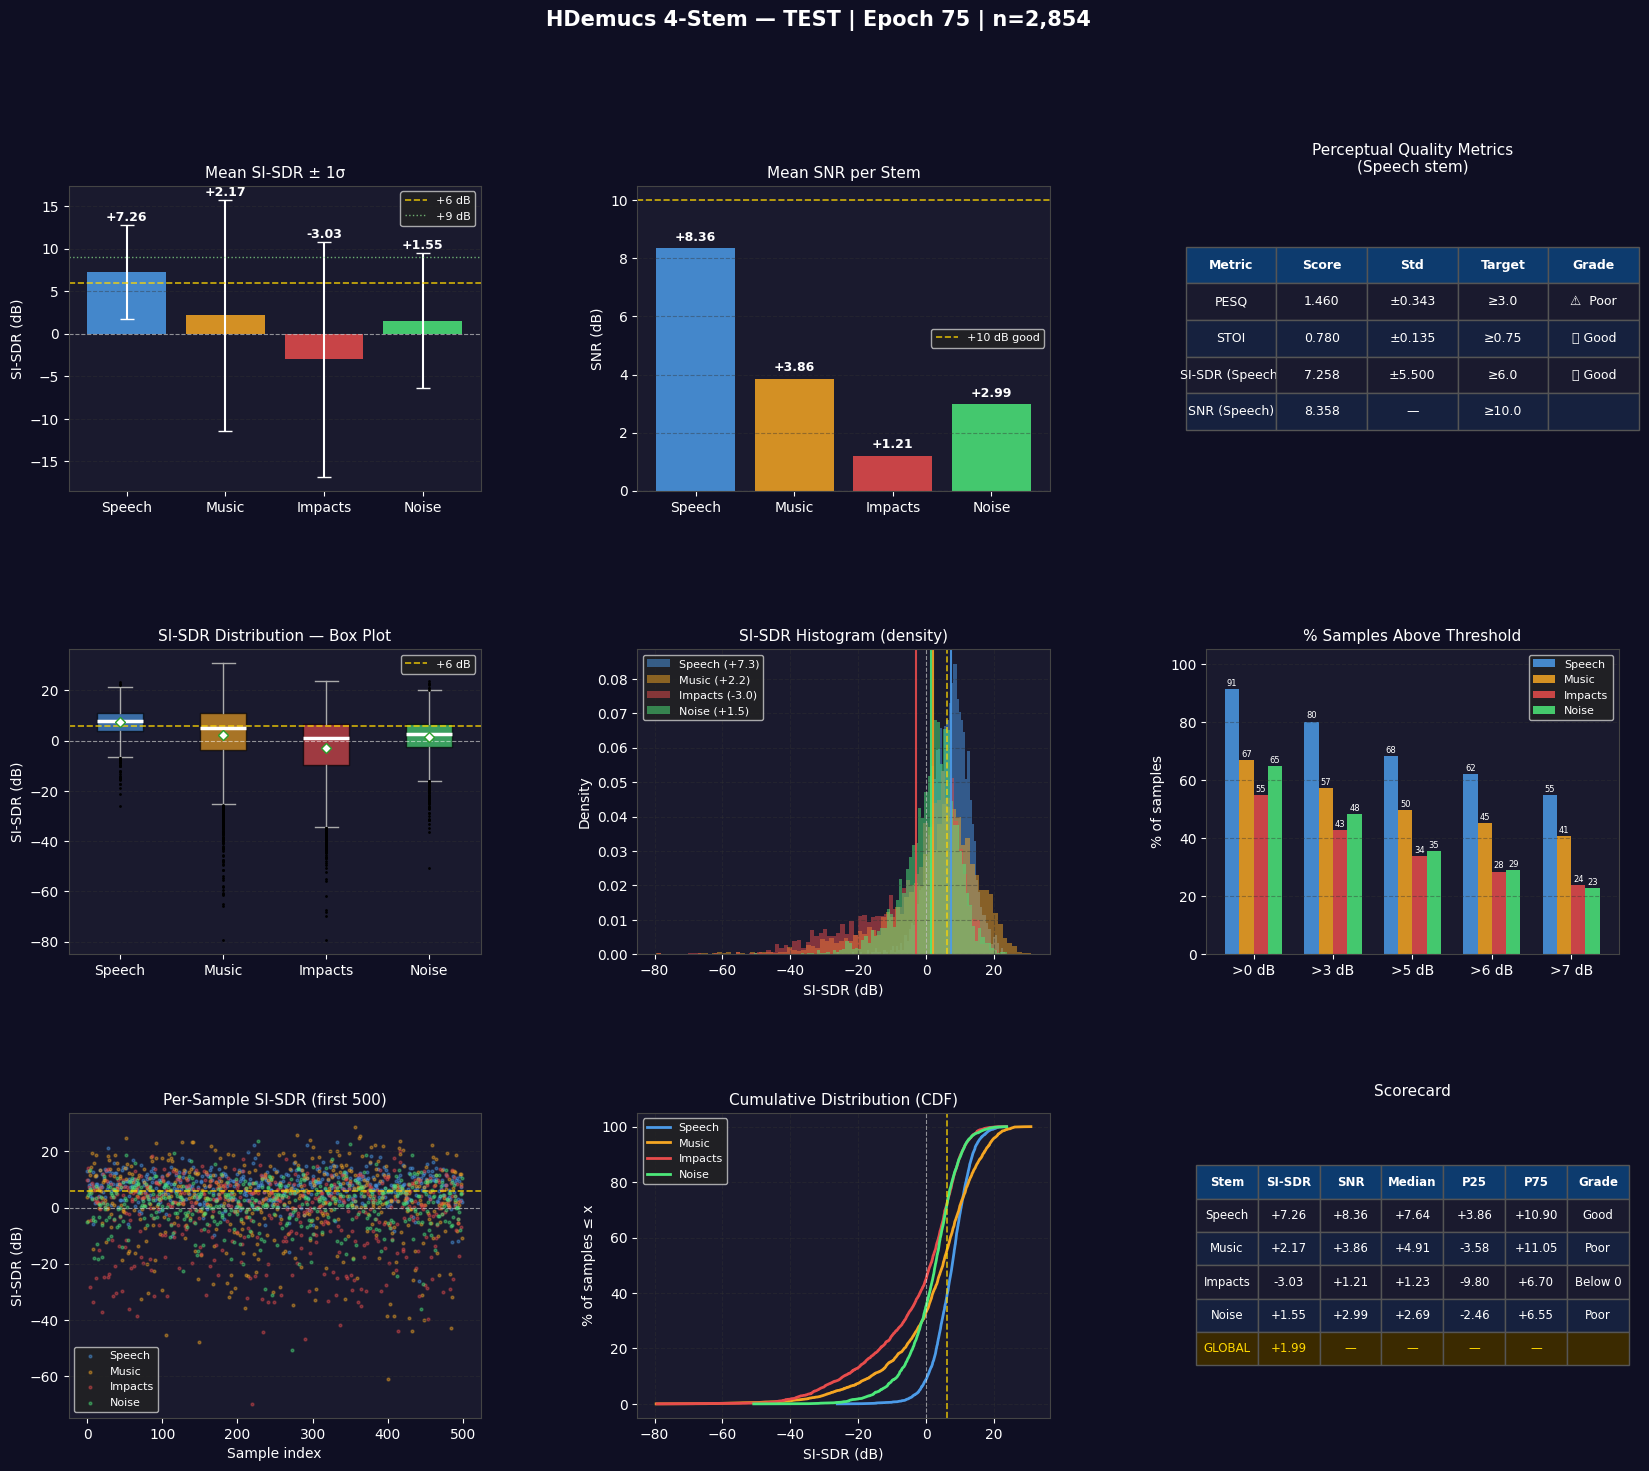

✅ Test result plots → /kaggle/working/test_results.png
📄 Report → /kaggle/working/test_metrics.txt
HDemucs 4-Stem — Evaluation Report v3
Checkpoint       : sonic_4stem_best.pth
Epoch saved      : 75
Best val loss    : -21.7135
Split evaluated  : TEST
Total samples    : 2854
Clip duration    : 3s @ 16kHz stereo

── SI-SDR + SNR ──────────────────────────────────────────────
Stem         SI-SDR     SNR    Std     P10     P25     P75     P90  Grade
---------------------------------------------------------------------------
Speech        +7.26   +8.36   5.50   +0.38   +3.86  +10.90  +13.69  ✅ Good
Music         +2.17   +3.86  13.60  -16.22   -3.58  +11.05  +16.67  ⚠️  Poor
Impacts       -3.03   +1.21  13.80  -24.27   -9.80   +6.70  +10.18  ❌ Below 0
Noise         +1.55   +2.99   7.96   -8.42   -2.46   +6.55  +10.31  ⚠️  Poor
GLOBAL        +1.99

── Perceptual Metrics (Speech stem) ─────────────────────────
PESQ  : 1.4599 ± 0.3429  [1.0–4.5, ≥3.0=Good]  ⚠️  Poor
STOI  : 0.7798 ± 0.1347  [0.

In [2]:
# =============================================================================
# TEST EVALUATION — HDemucs 4-Stem  v3
# Added: PESQ, STOI, SNR improvement metrics + train/val/test loss curves
# Paste each section as a SEPARATE Kaggle notebook cell.
# Required input datasets:
#   - surya5510/lastttmodel   (checkpoint)
#   - surya5510/6stem-split   (pkl)
# =============================================================================

# ── CELL 1: imports & setup ───────────────────────────────────────────────────
%matplotlib inline
import os, pickle, random, warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as ta_transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import Dataset, DataLoader
from torchaudio.models import HDemucs
from torchaudio.pipelines import HDEMUCS_HIGH_MUSDB

warnings.filterwarnings('ignore')

# Install perceptual metrics
import subprocess
subprocess.run(['pip', 'install', 'pesq', 'pystoi', '-q'], check=False)

try:
    from pesq import pesq as pesq_fn
    PESQ_AVAILABLE = True
    print("✅ PESQ available")
except ImportError:
    PESQ_AVAILABLE = False
    print("⚠️  PESQ not available — install with: pip install pesq")

try:
    from pystoi import stoi as stoi_fn
    STOI_AVAILABLE = True
    print("✅ STOI available")
except ImportError:
    STOI_AVAILABLE = False
    print("⚠️  STOI not available — install with: pip install pystoi")

DARK = {
    'figure.facecolor': '#0f0f23',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'grid.color':       '#333',
    'grid.linestyle':   '--',
    'grid.alpha':       0.4,
}
plt.rcParams.update(DARK)

# ── Checkpoint paths — STRICT LOAD ───────────────────────────────────────────
CKPT_BEST   = "/kaggle/input/datasets/surya5510/lastttmodel/sonic_4stem_best.pth"
PKL_PATH    = "/kaggle/input/datasets/surya5510/6stem-split/6stem_splits.pkl"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
STEMS  = ['Speech', 'Music', 'Impacts', 'Noise']
COLORS = ['#4C9BE8', '#F5A623', '#E84C4C', '#4CE87A']
SR     = 16000

print(f"Device : {DEVICE}")
print(f"GPU    : {torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'N/A'}")


# ── CELL 2: load checkpoint + training curves ─────────────────────────────────
ckpt_path = CKPT_BEST

if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f"❌ CRITICAL ERROR: Checkpoint not found at {ckpt_path}. Please ensure 'surya5510/lastttmodel' is added as an input dataset.")

print(f"\n📦 Loading: {ckpt_path}")
ckpt = torch.load(ckpt_path, map_location='cpu')

trained_epoch = ckpt.get('epoch', '?')
best_val_loss = ckpt.get('best_val_loss', ckpt.get('val_loss', float('nan')))
saved_sisdr   = ckpt.get('sisdr', None)

print(f"\n📋 Checkpoint:")
print(f"   Epoch            : {trained_epoch}")
print(f"   Best val loss   : {best_val_loss:.4f}")
if saved_sisdr: print(f"   Global SI-SDR   : {saved_sisdr:.4f} dB")
print(f"   Keys             : {list(ckpt.keys())}")

# ── Training curves ───────────────────────────────────────────────────────────
hist = ckpt.get('epoch_history', None)

if hist and len(hist.get('epoch', [])) > 0:
    n_hist     = len(hist['epoch'])
    epochs_h   = hist['epoch']
    val_loss_h = hist.get('val_loss',  [None]*n_hist)
    train_loss_h = hist.get('train_loss', [None]*n_hist)  # if recorded
    speech_h   = hist.get('Speech',   [None]*n_hist)
    music_h    = hist.get('Music',    [None]*n_hist)
    impacts_h  = hist.get('Impacts',  [None]*n_hist)
    noise_h    = hist.get('Noise',    [None]*n_hist)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(
        f'Training History — {n_hist} epochs | Best ep: {trained_epoch}',
        fontsize=13, fontweight='bold', color='white'
    )

    # Loss curves (val + train if available)
    ax = axes[0]
    vl_pts = [(e, v) for e, v in zip(epochs_h, val_loss_h) if v is not None]
    if vl_pts:
        ep_v, vl_v = zip(*vl_pts)
        ax.plot(ep_v, vl_v, color='#E84C4C', linewidth=2,
                marker='o', markersize=3, label='Val Loss')
        best_idx = int(np.argmin(vl_v))
        ax.axvline(ep_v[best_idx], color='gold', linewidth=1.2, linestyle='--',
                   label=f'Best ep {ep_v[best_idx]} ({vl_v[best_idx]:.2f})')

    tl_pts = [(e, v) for e, v in zip(epochs_h, train_loss_h) if v is not None]
    if tl_pts:
        ep_t, tl_t = zip(*tl_pts)
        ax.plot(ep_t, tl_t, color='#4C9BE8', linewidth=2,
                marker='s', markersize=3, label='Train Loss', alpha=0.8)

    ax.set_title('Loss Curves (Val / Train)', color='white')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(fontsize=9, facecolor='#222', labelcolor='white')
    ax.grid(True)

    # Per-stem SI-SDR
    ax = axes[1]
    for stem, color, series in zip(STEMS, COLORS,
                                   [speech_h, music_h, impacts_h, noise_h]):
        pts = [(e, v) for e, v in zip(epochs_h, series) if v is not None]
        if pts:
            ep_s, v_s = zip(*pts)
            ax.plot(ep_s, v_s, color=color, linewidth=2,
                    marker='o', markersize=3, label=stem)
    ax.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axhline(6, color='gold',  linewidth=1.0, linestyle='--', alpha=0.7,
               label='+6 dB target')
    ax.set_title('Per-Stem SI-SDR over Epochs', color='white')
    ax.set_xlabel('Epoch'); ax.set_ylabel('SI-SDR (dB)')
    ax.legend(fontsize=9, facecolor='#222', labelcolor='white')
    ax.grid(True)

    plt.tight_layout()
    plt.savefig('/kaggle/working/training_curves.png', dpi=150,
                bbox_inches='tight', facecolor='#0f0f23')
    plt.show()
    print("✅ Training curves → /kaggle/working/training_curves.png")
else:
    print("\n⚠️  No epoch_history in checkpoint — training curves skipped.")
    print("   (This is normal if 'epoch_history' wasn't saved in the checkpoint dict during training).")

# ── CELL 3: dataset + model ───────────────────────────────────────────────────
DURATION = 3

class SonicMixer4Stem(Dataset):
    def __init__(self, speech_list, noise_dict, sr=SR, duration=DURATION):
        self.speech      = speech_list
        self.noise       = noise_dict
        self.sr          = sr
        self.num_samples = sr * duration

    def _prep(self, path):
        wav, sr = torchaudio.load(path)
        if sr != self.sr:
            wav = ta_transforms.Resample(sr, self.sr)(wav)
        if wav.shape[0] == 1:   wav = wav.repeat(2, 1)
        elif wav.shape[0] > 2:  wav = wav[:2, :]
        if wav.shape[1] >= self.num_samples:
            wav = wav[:, :self.num_samples]
        else:
            wav = F.pad(wav, (0, self.num_samples - wav.shape[1]))
        return wav

    def __getitem__(self, idx):
        vocal   = self._prep(self.speech[idx % len(self.speech)])
        music   = self._prep(random.choice(self.noise['Music']))
        impacts = self._prep(random.choice(self.noise['Impacts']))
        alert   = self._prep(random.choice(self.noise['Alerts']))
        env     = self._prep(random.choice(self.noise['Environmental']))
        mech    = self._prep(random.choice(self.noise['Mechanical']))
        noise_stem = (alert + env + mech) * 0.6
        mixture    = vocal + 0.7*music + 0.7*impacts + 0.7*noise_stem
        targets    = torch.stack([vocal, music, impacts, noise_stem], dim=0)
        return mixture, targets

    def __len__(self): return len(self.speech)


print("📂 Loading splits...")
with open(PKL_PATH, "rb") as f:
    data = pickle.load(f)

if 'v_test' in data:
    speech_eval = data['v_test']
    noise_eval  = {k: v['test'] for k, v in data['noise_split'].items()}
    split_name  = 'TEST'
else:
    speech_eval = data['v_val']
    noise_eval  = {k: v['val']  for k, v in data['noise_split'].items()}
    split_name  = 'VAL'
print(f"   Split: {split_name} | {len(speech_eval)} files | {DURATION}s clips")

eval_loader = DataLoader(
    SonicMixer4Stem(speech_eval, noise_eval),
    batch_size=4, shuffle=False, num_workers=2, pin_memory=True
)
print(f"   Batches: {len(eval_loader):,}")

print("\n🧠 Building model...")
model = HDemucs(sources=STEMS, audio_channels=2)
pretrained = HDEMUCS_HIGH_MUSDB.get_model().state_dict()
my_dict = model.state_dict()
matched = {k: v for k, v in pretrained.items()
           if k in my_dict and v.shape == my_dict[k].shape}
my_dict.update(matched)
model.load_state_dict(my_dict)
model = nn.DataParallel(model).to(DEVICE)
model.module.load_state_dict(ckpt['model'])
model.eval()
print(f"   ✅ Epoch {trained_epoch} | best_val_loss {best_val_loss:.4f}")


# ── CELL 4: evaluation — SI-SDR + PESQ + STOI + SNR ─────────────────────────
def compute_sisdr(estimate, target, eps=1e-8):
    e = estimate.reshape(estimate.shape[0], -1)
    t = target.reshape(target.shape[0], -1)
    e = e - e.mean(-1, keepdim=True)
    t = t - t.mean(-1, keepdim=True)
    alpha = (e * t).sum(-1, keepdim=True) / ((t**2).sum(-1, keepdim=True) + eps)
    t_s = alpha * t
    return 10 * torch.log10((t_s**2).sum(-1) / ((e - t_s).pow(2).sum(-1) + eps) + eps)

def compute_snr(estimate, target, eps=1e-8):
    """SNR improvement: SNR(estimate vs target) - SNR(mixture vs target)"""
    e = estimate.reshape(estimate.shape[0], -1)
    t = target.reshape(target.shape[0], -1)
    signal_power = (t ** 2).sum(-1)
    noise_power  = ((e - t) ** 2).sum(-1) + eps
    return 10 * torch.log10(signal_power / noise_power + eps)

def safe_pesq(ref, deg, sr):
    """PESQ on mono 16kHz numpy arrays. Returns score or NaN on failure."""
    try:
        mode = 'wb' if sr == 16000 else 'nb'
        return float(pesq_fn(sr, ref, deg, mode))
    except Exception:
        return float('nan')

def safe_stoi(ref, deg, sr):
    """STOI on mono numpy arrays. Returns score or NaN on failure."""
    try:
        return float(stoi_fn(ref, deg, sr, extended=False))
    except Exception:
        return float('nan')

print(f"\n🔍 Evaluating on {split_name} ({len(eval_loader)} batches)...")
print(f"   SI-SDR: always  |  SNR: always")
print(f"   PESQ  : {'✅' if PESQ_AVAILABLE else '❌ skipped'}  |  "
      f"STOI  : {'✅' if STOI_AVAILABLE else '❌ skipped'}")
print(f"   Note: PESQ/STOI computed on Speech stem only (perceptual speech metrics)\n")

# Accumulators
stem_sisdr = [[] for _ in range(4)]
stem_snr   = [[] for _ in range(4)]
pesq_scores, stoi_scores = [], []

# Limit PESQ/STOI to first 200 batches — they're slow (CPU loop)
PESQ_STOI_LIMIT = 200

with torch.no_grad():
    for i, (mix, targets) in enumerate(eval_loader):
        if i % 100 == 0:
            print(f"   [{i:4d}/{len(eval_loader)}]  "
                  f"pesq/stoi batches: {min(i, PESQ_STOI_LIMIT)}/{PESQ_STOI_LIMIT}",
                  end='\r')
        mix, targets = mix.to(DEVICE), targets.to(DEVICE)
        estimates    = model(mix)

        # SI-SDR and SNR for all 4 stems
        for s in range(4):
            stem_sisdr[s].extend(
                compute_sisdr(estimates[:, s], targets[:, s]).cpu().tolist()
            )
            stem_snr[s].extend(
                compute_snr(estimates[:, s], targets[:, s]).cpu().tolist()
            )

        # PESQ + STOI on Speech stem (index 0), mono channel 0
        if i < PESQ_STOI_LIMIT and (PESQ_AVAILABLE or STOI_AVAILABLE):
            est_speech = estimates[:, 0, 0, :].cpu().numpy()  # (B, T)
            tgt_speech = targets[:,  0, 0, :].cpu().numpy()   # (B, T)
            for b in range(est_speech.shape[0]):
                ref = tgt_speech[b]
                deg = est_speech[b]
                if PESQ_AVAILABLE:
                    pesq_scores.append(safe_pesq(ref, deg, SR))
                if STOI_AVAILABLE:
                    stoi_scores.append(safe_stoi(ref, deg, SR))

print(f"\n   Done — {len(stem_sisdr[0])} samples evaluated")

# ── Stats ─────────────────────────────────────────────────────────────────────
stem_mean   = [float(np.mean(v))          for v in stem_sisdr]
stem_std    = [float(np.std(v))           for v in stem_sisdr]
stem_median = [float(np.median(v))        for v in stem_sisdr]
stem_p10    = [float(np.percentile(v,10)) for v in stem_sisdr]
stem_p25    = [float(np.percentile(v,25)) for v in stem_sisdr]
stem_p75    = [float(np.percentile(v,75)) for v in stem_sisdr]
stem_p90    = [float(np.percentile(v,90)) for v in stem_sisdr]
stem_snr_mean = [float(np.mean(v))        for v in stem_snr]
global_mean = float(np.mean(stem_mean))

pesq_mean = float(np.nanmean(pesq_scores)) if pesq_scores else float('nan')
pesq_std  = float(np.nanstd(pesq_scores))  if pesq_scores else float('nan')
stoi_mean = float(np.nanmean(stoi_scores)) if stoi_scores else float('nan')
stoi_std  = float(np.nanstd(stoi_scores))  if stoi_scores else float('nan')

def grade_sisdr(db):
    if db >= 9:  return '✅ Great'
    if db >= 6:  return '✅ Good'
    if db >= 3:  return '📈 Fair'
    if db >= 0:  return '⚠️  Poor'
    return '❌ Below 0'

def grade_pesq(p):
    if np.isnan(p):  return 'N/A'
    if p >= 4.0:     return '✅ Excellent'
    if p >= 3.0:     return '✅ Good'
    if p >= 2.0:     return '📈 Fair'
    return '⚠️  Poor'

def grade_stoi(s):
    if np.isnan(s):  return 'N/A'
    if s >= 0.90:    return '✅ Excellent'
    if s >= 0.75:    return '✅ Good'
    if s >= 0.60:    return '📈 Fair'
    return '⚠️  Poor'

# ── Print results ─────────────────────────────────────────────────────────────
print(f"\n{'='*72}")
print(f"  {split_name}  |  Epoch {trained_epoch}  |  Global SI-SDR: {global_mean:+.2f} dB")
print(f"  {'Stem':<10} {'SI-SDR':>8} {'SNR':>7} {'Std':>6} {'P25':>7} {'P75':>7}  Grade")
print(f"  {'-'*68}")
for s, name in enumerate(STEMS):
    print(f"  {name:<10} {stem_mean[s]:>+8.2f} {stem_snr_mean[s]:>+7.2f} "
          f"{stem_std[s]:>6.2f} {stem_p25[s]:>+7.2f} {stem_p75[s]:>+7.2f}"
          f"  {grade_sisdr(stem_mean[s])}")
print(f"{'='*72}")

print(f"\n  ── Perceptual Quality (Speech stem) ──────────────────────────────")
print(f"  Metric   Score       Grade        Range         Interpretation")
print(f"  {'─'*65}")
if not np.isnan(pesq_mean):
    print(f"  PESQ     {pesq_mean:5.3f}±{pesq_std:.3f}  {grade_pesq(pesq_mean):<12}  "
          f"[1.0–4.5]     ≥3.0 = Good, ≥4.0 = Excellent")
else:
    print(f"  PESQ     N/A (library not available)")

if not np.isnan(stoi_mean):
    print(f"  STOI     {stoi_mean:5.3f}±{stoi_std:.3f}  {grade_stoi(stoi_mean):<12}  "
          f"[0.0–1.0]     ≥0.75 = Good, ≥0.90 = Excellent")
else:
    print(f"  STOI     N/A (library not available)")

print(f"  SNR(Sp)  {stem_snr_mean[0]:+.2f} dB       {'✅ Good' if stem_snr_mean[0]>10 else '📈 Fair' if stem_snr_mean[0]>5 else '⚠️  Low':<12}  "
      f"higher=better  Signal to noise ratio of separated speech")
print(f"{'='*72}")

# ── Loss interpretation guide ─────────────────────────────────────────────────
print(f"""
  ── How to Read the Loss Value ─────────────────────────────────────────────
  Your val loss ({best_val_loss:.2f}) is a composite training signal, not a
  perceptual score. Use these objective metrics to judge quality:

  SI-SDR  : direct separation quality (dB, higher = better)
  PESQ    : perceptual speech quality after separation (1.0–4.5)
  STOI    : speech intelligibility (0.0–1.0, closer to 1 = more intelligible)
  SNR     : signal-to-noise ratio of separated speech (dB)

  Loss "low enough" when:
    Speech SI-SDR > 6 dB  AND  PESQ > 3.0  AND  STOI > 0.75
  Current:
    Speech SI-SDR : {stem_mean[0]:+.2f} dB  {'✅' if stem_mean[0]>6 else '📈'}
    PESQ          : {pesq_mean:.3f}          {grade_pesq(pesq_mean)}
    STOI          : {stoi_mean:.3f}          {grade_stoi(stoi_mean)}
""")


# ── CELL 5: plots ─────────────────────────────────────────────────────────────
thresholds = [0, 3, 5, 6, 7]
n_samples  = len(stem_sisdr[0])

fig = plt.figure(figsize=(20, 16))
fig.suptitle(
    f'HDemucs 4-Stem — {split_name} | Epoch {trained_epoch} | n={n_samples:,}',
    fontsize=15, fontweight='bold', color='white', y=0.99
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.38)

# Plot 1: Mean SI-SDR bar
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(STEMS, stem_mean, color=COLORS, alpha=0.85,
               yerr=stem_std, capsize=5,
               error_kw={'linewidth': 1.5, 'ecolor': 'white'})
ax1.axhline(0, color='white',   linewidth=0.8, linestyle='--', alpha=0.5)
ax1.axhline(6, color='gold',    linewidth=1.2, linestyle='--', alpha=0.8, label='+6 dB')
ax1.axhline(9, color='#90ee90', linewidth=1.0, linestyle=':', alpha=0.7,  label='+9 dB')
for bar, val, std in zip(bars, stem_mean, stem_std):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.15,
             f'{val:+.2f}', ha='center', va='bottom', fontsize=9,
             color='white', fontweight='bold')
ax1.set_title('Mean SI-SDR ± 1σ', color='white', fontsize=11)
ax1.set_ylabel('SI-SDR (dB)')
ax1.legend(fontsize=8, facecolor='#222', labelcolor='white')
ax1.grid(True, axis='y')

# Plot 2: SNR bar
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(STEMS, stem_snr_mean, color=COLORS, alpha=0.85)
ax2.axhline(0,  color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax2.axhline(10, color='gold',  linewidth=1.2, linestyle='--', alpha=0.8, label='+10 dB good')
for bar, val in zip(bars2, stem_snr_mean):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.15 if val >= 0 else bar.get_height() - 1.0,
             f'{val:+.2f}', ha='center', va='bottom', fontsize=9,
             color='white', fontweight='bold')
ax2.set_title('Mean SNR per Stem', color='white', fontsize=11)
ax2.set_ylabel('SNR (dB)')
ax2.legend(fontsize=8, facecolor='#222', labelcolor='white')
ax2.grid(True, axis='y')

# Plot 3: PESQ + STOI gauge bars
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')
metrics_data = []
if not np.isnan(pesq_mean):
    metrics_data.append(('PESQ', pesq_mean, pesq_std, 1.0, 4.5, 3.0, grade_pesq(pesq_mean)))
if not np.isnan(stoi_mean):
    metrics_data.append(('STOI', stoi_mean, stoi_std, 0.0, 1.0, 0.75, grade_stoi(stoi_mean)))
metrics_data.append(('SI-SDR\n(Speech)', stem_mean[0], stem_std[0], -5, 12, 6.0, grade_sisdr(stem_mean[0])))
metrics_data.append(('SNR\n(Speech)', stem_snr_mean[0], 0, -5, 20, 10.0, ''))

col_labels = ['Metric', 'Score', 'Std', 'Target', 'Grade']
cell_data = []
for name, val, std, lo, hi, target, gr in metrics_data:
    cell_data.append([
        name.replace('\n', ' '),
        f'{val:.3f}',
        f'±{std:.3f}' if std > 0 else '—',
        f'≥{target}',
        gr
    ])
tbl = ax3.table(cellText=cell_data, colLabels=col_labels,
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.1, 2.2)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#555')
    if row == 0:
        cell.set_facecolor('#0d3b6e'); cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#16213e'); cell.set_text_props(color='white')
    else:
        cell.set_facecolor('#1a1a2e'); cell.set_text_props(color='white')
ax3.set_title('Perceptual Quality Metrics\n(Speech stem)', color='white', fontsize=11, pad=10)

# Plot 4: Box plot
ax4 = fig.add_subplot(gs[1, 0])
bp = ax4.boxplot([stem_sisdr[s] for s in range(4)], labels=STEMS,
                 patch_artist=True,
                 medianprops=dict(color='white', linewidth=2.5),
                 meanprops=dict(marker='D', markerfacecolor='white', markersize=5),
                 showmeans=True,
                 whiskerprops=dict(color='#aaa'), capprops=dict(color='#aaa'),
                 flierprops=dict(marker='.', color='#666', markersize=2))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.65)
ax4.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax4.axhline(6, color='gold',  linewidth=1.2, linestyle='--', alpha=0.8, label='+6 dB')
ax4.set_title('SI-SDR Distribution — Box Plot', color='white', fontsize=11)
ax4.set_ylabel('SI-SDR (dB)')
ax4.legend(fontsize=8, facecolor='#222', labelcolor='white')
ax4.grid(True, axis='y')

# Plot 5: Histogram
ax5 = fig.add_subplot(gs[1, 1])
for s in range(4):
    ax5.hist(stem_sisdr[s], bins=80, alpha=0.5,
             color=COLORS[s], label=f'{STEMS[s]} ({stem_mean[s]:+.1f})', density=True)
    ax5.axvline(stem_mean[s], color=COLORS[s], linewidth=1.5, alpha=0.9)
ax5.axvline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax5.axvline(6, color='gold',  linewidth=1.2, linestyle='--', alpha=0.8)
ax5.set_title('SI-SDR Histogram (density)', color='white', fontsize=11)
ax5.set_xlabel('SI-SDR (dB)'); ax5.set_ylabel('Density')
ax5.legend(fontsize=8, facecolor='#222', labelcolor='white')
ax5.grid(True)

# Plot 6: % above threshold
ax6 = fig.add_subplot(gs[1, 2])
x, bw = np.arange(len(thresholds)), 0.18
for si, (stem, color) in enumerate(zip(STEMS, COLORS)):
    pcts_th = [100.0 * sum(v > t for v in stem_sisdr[si]) / n_samples
               for t in thresholds]
    ax6.bar(x + si*bw, pcts_th, bw, label=stem, color=color, alpha=0.85)
    for xi, p in zip(x, pcts_th):
        if p > 5:
            ax6.text(xi + si*bw, p + 0.5, f'{p:.0f}', ha='center',
                     va='bottom', fontsize=6, color='white')
ax6.set_xticks(x + bw*1.5)
ax6.set_xticklabels([f'>{t} dB' for t in thresholds])
ax6.set_title('% Samples Above Threshold', color='white', fontsize=11)
ax6.set_ylabel('% of samples'); ax6.set_ylim(0, 105)
ax6.legend(fontsize=8, facecolor='#222', labelcolor='white')
ax6.grid(True, axis='y')

# Plot 7: Per-sample scatter (first 500)
ax7 = fig.add_subplot(gs[2, 0])
n_plot = min(500, n_samples)
for s in range(4):
    ax7.scatter(np.arange(n_plot), stem_sisdr[s][:n_plot],
                s=4, color=COLORS[s], alpha=0.4, label=STEMS[s])
ax7.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax7.axhline(6, color='gold',  linewidth=1.2, linestyle='--', alpha=0.8)
ax7.set_title(f'Per-Sample SI-SDR (first {n_plot})', color='white', fontsize=11)
ax7.set_xlabel('Sample index'); ax7.set_ylabel('SI-SDR (dB)')
ax7.legend(fontsize=8, facecolor='#222', labelcolor='white')
ax7.grid(True, axis='y')

# Plot 8: CDF
ax8 = fig.add_subplot(gs[2, 1])
for s in range(4):
    sv  = np.sort(stem_sisdr[s])
    cdf = np.arange(1, len(sv)+1) / len(sv)
    ax8.plot(sv, cdf*100, color=COLORS[s], linewidth=2, label=STEMS[s])
ax8.axvline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax8.axvline(6, color='gold',  linewidth=1.2, linestyle='--', alpha=0.8)
ax8.set_title('Cumulative Distribution (CDF)', color='white', fontsize=11)
ax8.set_xlabel('SI-SDR (dB)'); ax8.set_ylabel('% of samples ≤ x')
ax8.legend(fontsize=8, facecolor='#222', labelcolor='white')
ax8.grid(True)

# Plot 9: Scorecard
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')
col_labels9 = ['Stem', 'SI-SDR', 'SNR', 'Median', 'P25', 'P75', 'Grade']
cell_data9  = []
for s, name in enumerate(STEMS):
    cell_data9.append([
        name, f'{stem_mean[s]:+.2f}', f'{stem_snr_mean[s]:+.2f}',
        f'{stem_median[s]:+.2f}', f'{stem_p25[s]:+.2f}', f'{stem_p75[s]:+.2f}',
        grade_sisdr(stem_mean[s]).replace('✅','').replace('📈','').replace('⚠️','').replace('❌','').strip()
    ])
cell_data9.append(['GLOBAL', f'{global_mean:+.2f}', '—', '—', '—', '—', ''])
tbl9 = ax9.table(cellText=cell_data9, colLabels=col_labels9,
                 loc='center', cellLoc='center')
tbl9.auto_set_font_size(False); tbl9.set_fontsize(8.5); tbl9.scale(1.05, 2.0)
for (row, col), cell in tbl9.get_celld().items():
    cell.set_edgecolor('#555')
    if row == 0:
        cell.set_facecolor('#0d3b6e'); cell.set_text_props(color='white', fontweight='bold')
    elif row == len(cell_data9):
        cell.set_facecolor('#3b2a00'); cell.set_text_props(color='#FFD700')
    elif row % 2 == 0:
        cell.set_facecolor('#16213e'); cell.set_text_props(color='white')
    else:
        cell.set_facecolor('#1a1a2e'); cell.set_text_props(color='white')
ax9.set_title('Scorecard', color='white', fontsize=11, pad=12)

plt.savefig('/kaggle/working/test_results.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f23')
plt.show()
print("✅ Test result plots → /kaggle/working/test_results.png")


# ── CELL 6: text report ───────────────────────────────────────────────────────
report_path = '/kaggle/working/test_metrics.txt'
with open(report_path, 'w') as f:
    f.write("HDemucs 4-Stem — Evaluation Report v3\n")
    f.write("=" * 65 + "\n")
    f.write(f"Checkpoint       : {os.path.basename(ckpt_path)}\n")
    f.write(f"Epoch saved      : {trained_epoch}\n")
    f.write(f"Best val loss    : {best_val_loss:.4f}\n")
    f.write(f"Split evaluated  : {split_name}\n")
    f.write(f"Total samples    : {n_samples}\n")
    f.write(f"Clip duration    : {DURATION}s @ {SR//1000}kHz stereo\n")
    f.write("\n── SI-SDR + SNR ──────────────────────────────────────────────\n")
    f.write(f"{'Stem':<10} {'SI-SDR':>8} {'SNR':>7} {'Std':>6} "
            f"{'P10':>7} {'P25':>7} {'P75':>7} {'P90':>7}  Grade\n")
    f.write("-" * 75 + "\n")
    for s, name in enumerate(STEMS):
        f.write(
            f"{name:<10} {stem_mean[s]:>+8.2f} {stem_snr_mean[s]:>+7.2f} "
            f"{stem_std[s]:>6.2f} {stem_p10[s]:>+7.2f} {stem_p25[s]:>+7.2f} "
            f"{stem_p75[s]:>+7.2f} {stem_p90[s]:>+7.2f}  {grade_sisdr(stem_mean[s])}\n"
        )
    f.write(f"{'GLOBAL':<10} {global_mean:>+8.2f}\n")
    f.write("\n── Perceptual Metrics (Speech stem) ─────────────────────────\n")
    f.write(f"PESQ  : {pesq_mean:.4f} ± {pesq_std:.4f}  "
            f"[1.0–4.5, ≥3.0=Good]  {grade_pesq(pesq_mean)}\n")
    f.write(f"STOI  : {stoi_mean:.4f} ± {stoi_std:.4f}  "
            f"[0.0–1.0, ≥0.75=Good] {grade_stoi(stoi_mean)}\n")
    f.write(f"SNR   : {stem_snr_mean[0]:+.2f} dB  [higher=better]\n")
    f.write("\n── Threshold breakdown ───────────────────────────────────────\n")
    for t in thresholds:
        counts = [sum(v > t for v in stem_sisdr[s]) for s in range(4)]
        pcts   = [100.0*c/n_samples for c in counts]
        f.write(f"  >{t:+2d} dB : "
                + "  ".join(f"{n}={p:.0f}%" for n, p in zip(STEMS, pcts))
                + "\n")
    f.write("\n── Loss Interpretation ───────────────────────────────────────\n")
    f.write(f"Raw val loss ({best_val_loss:.2f}) is a composite training signal.\n")
    f.write("Use SI-SDR/PESQ/STOI as objective quality indicators.\n")
    f.write("Loss is 'good enough' when: SI-SDR>6dB AND PESQ>3.0 AND STOI>0.75\n")

print(f"📄 Report → {report_path}")
with open(report_path) as f:
    print(f.read())
print("✅ EVALUATION COMPLETE")

Device : cuda
GPU    : Tesla T4

📦 Loading checkpoint: /kaggle/input/datasets/surya5510/newwhdemucs4stem55/sonic_4stem_best.pth

📋 Checkpoint Contents:
   Epoch saved        : 59
   Best val loss      : -20.4807
   Global SI-SDR      : 2.9556 dB
   Epochs no improve : 0
   Keys in ckpt       : ['epoch', 'model', 'val_loss', 'sisdr', 'best_val_loss', 'epochs_no_improve']

⚠️  No epoch_history key found in this checkpoint.
   Continuing to evaluation...
📂 Loading dataset splits...
   PKL keys : ['metadata', 'v_train', 'v_val', 'v_test', 'noise_split']
   Split : TEST  |  2854 speech files  |  3s clips
   Batches : 714

🧠 Building & loading model...
   ✅ Epoch 59 | best_val_loss -20.4807

🔍 Evaluating on TEST (714 batches)...
   [ 700/714]
   Done — 2854 samples evaluated

  TEST  |  Epoch 59  |  Global Mean SI-SDR: +2.10 dB
  Stem          Mean    Std   Median     P25     P75  Grade
  ----------------------------------------------------------------
  Speech       +7.16   5.49    +7.35   

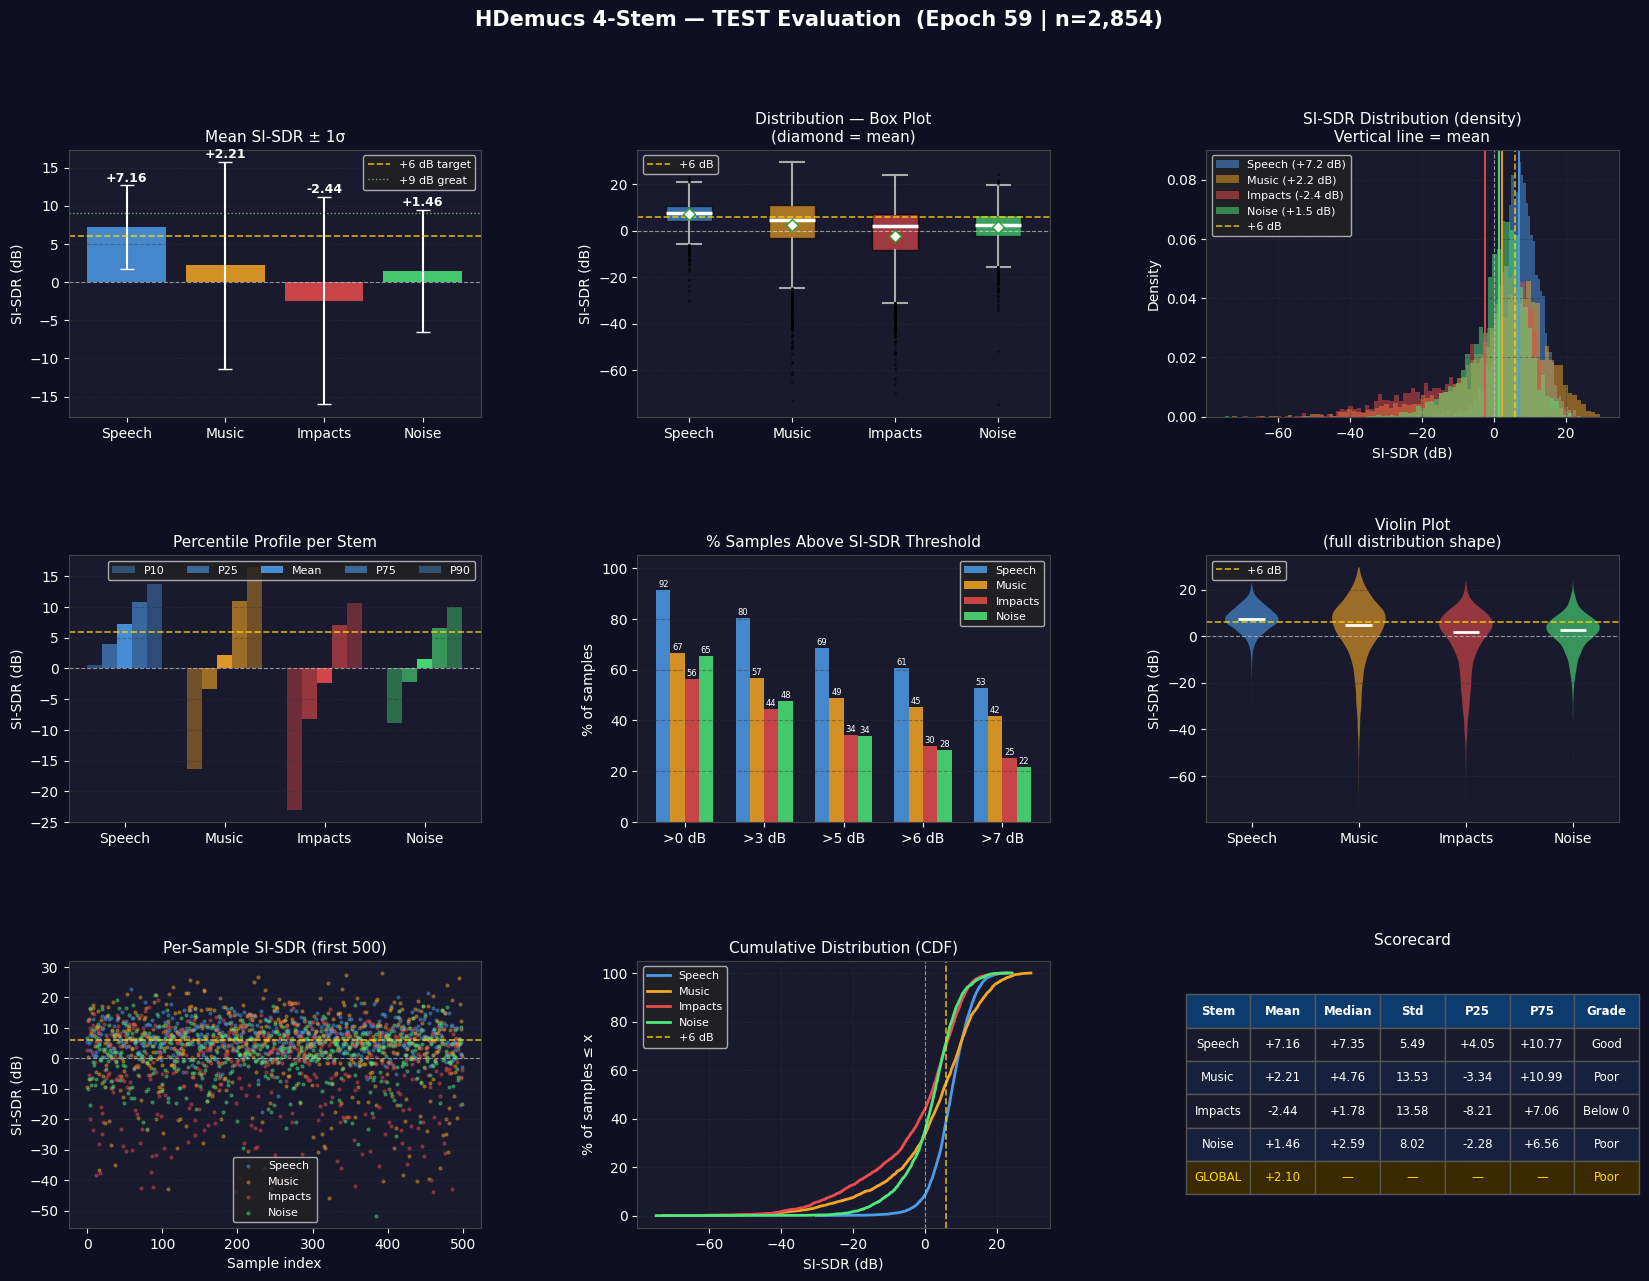

✅ Test result plots saved → /kaggle/working/test_results.png
📄 Report → /kaggle/working/test_metrics.txt
HDemucs 4-Stem — Evaluation Report
Checkpoint       : sonic_4stem_best.pth
Epoch saved      : 59
Best val loss    : -20.4807
Split evaluated  : TEST
Total samples    : 2854
Clip duration    : 3s @ 16kHz stereo

Stem          Mean    Std   Median     P10     P25     P75     P90  Grade
------------------------------------------------------------------------
Speech       +7.16   5.49    +7.35   +0.62   +4.05  +10.77  +13.81  ✅ Good
Music        +2.21  13.53    +4.76  -16.42   -3.34  +10.99  +16.44  ⚠️  Poor
Impacts      -2.44  13.58    +1.78  -23.05   -8.21   +7.06  +10.71  ❌ Below 0
Noise        +1.46   8.02    +2.59   -8.83   -2.28   +6.56  +10.04  ⚠️  Poor
------------------------------------------------------------------------
GLOBAL       +2.10

Threshold breakdown:
  >+0 dB : Speech=92%  Music=67%  Impacts=56%  Noise=65%
  >+3 dB : Speech=80%  Music=57%  Impacts=44%  Noise=48%
  

In [2]:
# # =============================================================================
# # TEST EVALUATION — HDemucs 4-Stem  v2
# # No hardcoded history. All plots driven by live checkpoint + val/test data.
# # Paste each section as a SEPARATE Kaggle notebook cell.
# # =============================================================================

# # ── CELL 1: imports & setup ───────────────────────────────────────────────────
# %matplotlib inline
# import os, pickle, random, warnings
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torchaudio
# import torchaudio.transforms as ta_transforms
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# from torch.utils.data import Dataset, DataLoader
# from torchaudio.models import HDemucs
# from torchaudio.pipelines import HDEMUCS_HIGH_MUSDB

# warnings.filterwarnings('ignore')
# DARK = {
#     'figure.facecolor': '#0f0f23',
#     'axes.facecolor':   '#1a1a2e',
#     'axes.edgecolor':   '#444',
#     'axes.labelcolor':  'white',
#     'xtick.color':      'white',
#     'ytick.color':      'white',
#     'text.color':       'white',
#     'grid.color':       '#333',
#     'grid.linestyle':   '--',
#     'grid.alpha':       0.4,
# }
# plt.rcParams.update(DARK)

# # UPDATED PATHS TO POINT TO THE NEW DATASET
# CKPT_BEST   = "/kaggle/input/datasets/surya5510/newwhdemucs4stem55/sonic_4stem_best.pth"
# CKPT_LATEST = "/kaggle/input/datasets/surya5510/newwhdemucs4stem55/sonic_4stem.pth"
# PKL_PATH    = "/kaggle/input/datasets/surya5510/6stem-split/6stem_splits.pkl"

# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# STEMS  = ['Speech', 'Music', 'Impacts', 'Noise']
# COLORS = ['#4C9BE8', '#F5A623', '#E84C4C', '#4CE87A']
# print(f"Device : {DEVICE}")
# print(f"GPU    : {torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'N/A'}")


# # ── CELL 2: load checkpoint + show what's inside ─────────────────────────────
# ckpt_path = CKPT_BEST if os.path.exists(CKPT_BEST) else CKPT_LATEST
# print(f"\n📦 Loading checkpoint: {ckpt_path}")
# ckpt = torch.load(ckpt_path, map_location='cpu')

# trained_epoch = ckpt.get('epoch', '?')
# best_val_loss = ckpt.get('best_val_loss', ckpt.get('val_loss', float('nan')))
# saved_sisdr   = ckpt.get('sisdr', None)
# ckpt_lr       = ckpt.get('lr', None)
# ckpt_no_impr  = ckpt.get('epochs_no_improve', None)

# print(f"\n📋 Checkpoint Contents:")
# print(f"   Epoch saved        : {trained_epoch}")
# print(f"   Best val loss      : {best_val_loss:.4f}")
# if saved_sisdr is not None:
#     print(f"   Global SI-SDR      : {saved_sisdr:.4f} dB")
# if ckpt_lr is not None:
#     print(f"   LR at save         : {ckpt_lr:.7f}")
# if ckpt_no_impr is not None:
#     print(f"   Epochs no improve : {ckpt_no_impr}")
# print(f"   Keys in ckpt       : {list(ckpt.keys())}")

# # -- Training history (only from checkpoint, no hardcoding) -------------------
# hist = ckpt.get('epoch_history', None)

# if hist and len(hist.get('epoch', [])) > 0:
#     n_hist = len(hist['epoch'])
#     print(f"\n📈 Live epoch history found: {n_hist} epochs recorded")

#     epochs_h   = hist['epoch']
#     val_loss_h = hist.get('val_loss', [None]*n_hist)
#     speech_h   = hist.get('Speech',   [None]*n_hist)
#     music_h    = hist.get('Music',    [None]*n_hist)
#     impacts_h  = hist.get('Impacts',  [None]*n_hist)
#     noise_h    = hist.get('Noise',    [None]*n_hist)

#     fig, axes = plt.subplots(1, 2, figsize=(16, 5))
#     fig.suptitle(
#         f'Training History (live — {n_hist} epochs | best ep saved: {trained_epoch})',
#         fontsize=13, fontweight='bold', color='white'
#     )

#     # Val loss curve
#     ax = axes[0]
#     vl_pts  = [(e, v) for e, v in zip(epochs_h, val_loss_h) if v is not None]
#     if vl_pts:
#         ep_v, vl_v = zip(*vl_pts)
#         ax.plot(ep_v, vl_v, color='#E84C4C', linewidth=2, marker='o', markersize=4)
#         best_idx = int(np.argmin(vl_v))
#         ax.axvline(ep_v[best_idx], color='gold', linewidth=1.2, linestyle='--',
#                    label=f'Best ep {ep_v[best_idx]} ({vl_v[best_idx]:.2f})')
#         ax.legend(fontsize=9, facecolor='#222', labelcolor='white')
#     ax.set_title('Validation Loss', color='white')
#     ax.set_xlabel('Epoch');  ax.set_ylabel('Loss')
#     ax.grid(True)

#     # Per-stem SI-SDR
#     ax = axes[1]
#     for stem, color, series in zip(
#         STEMS, COLORS,
#         [speech_h, music_h, impacts_h, noise_h]
#     ):
#         pts = [(e, v) for e, v in zip(epochs_h, series) if v is not None]
#         if pts:
#             ep_s, v_s = zip(*pts)
#             ax.plot(ep_s, v_s, color=color, linewidth=2,
#                     marker='o', markersize=4, label=stem)
#     ax.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
#     ax.axhline(6, color='gold',  linewidth=1.0, linestyle='--', alpha=0.7,
#                label='+6 dB target')
#     ax.set_title('Per-Stem SI-SDR over Epochs', color='white')
#     ax.set_xlabel('Epoch');  ax.set_ylabel('SI-SDR (dB)')
#     ax.legend(fontsize=9, facecolor='#222', labelcolor='white')
#     ax.grid(True)

#     plt.tight_layout()
#     plt.savefig('/kaggle/working/training_curves.png', dpi=150,
#                 bbox_inches='tight', facecolor='#0f0f23')
#     plt.show()
#     print("✅ Training curves saved → /kaggle/working/training_curves.png")

# else:
#     print("\n⚠️  No epoch_history key found in this checkpoint.")
#     print("   Continuing to evaluation...")


# # ── CELL 3: dataset + model load ─────────────────────────────────────────────
# SR       = 16000
# DURATION = 3          # must match training (v7+)

# class SonicMixer4Stem(Dataset):
#     """
#     Deterministic eval version — no augmentation, no double-stacking,
#     no burst-trim on impacts (raw clips, consistent with val loop in training).
#     """
#     def __init__(self, speech_list, noise_dict, sr=SR, duration=DURATION):
#         self.speech      = speech_list
#         self.noise       = noise_dict
#         self.sr          = sr
#         self.num_samples = sr * duration

#     def _prep(self, path):
#         wav, sr = torchaudio.load(path)
#         if sr != self.sr:
#             wav = ta_transforms.Resample(sr, self.sr)(wav)
#         if wav.shape[0] == 1:
#             wav = wav.repeat(2, 1)
#         elif wav.shape[0] > 2:
#             wav = wav[:2, :]
#         if wav.shape[1] >= self.num_samples:
#             wav = wav[:, :self.num_samples]
#         else:
#             wav = F.pad(wav, (0, self.num_samples - wav.shape[1]))
#         return wav

#     def __getitem__(self, idx):
#         vocal   = self._prep(self.speech[idx % len(self.speech)])
#         music   = self._prep(random.choice(self.noise['Music']))
#         impacts = self._prep(random.choice(self.noise['Impacts']))
#         alert   = self._prep(random.choice(self.noise['Alerts']))
#         env     = self._prep(random.choice(self.noise['Environmental']))
#         mech    = self._prep(random.choice(self.noise['Mechanical']))
#         noise_stem = (alert + env + mech) * 0.6
#         mixture    = vocal + 0.7*music + 0.7*impacts + 0.7*noise_stem
#         targets    = torch.stack([vocal, music, impacts, noise_stem], dim=0)
#         return mixture, targets

#     def __len__(self):
#         return len(self.speech)


# print("📂 Loading dataset splits...")
# with open(PKL_PATH, "rb") as f:
#     data = pickle.load(f)
# print(f"   PKL keys : {list(data.keys())}")

# if 'v_test' in data:
#     speech_eval = data['v_test']
#     noise_eval  = {k: v['test'] for k, v in data['noise_split'].items()}
#     split_name  = 'TEST'
# else:
#     speech_eval = data['v_val']
#     noise_eval  = {k: v['val']  for k, v in data['noise_split'].items()}
#     split_name  = 'VAL'
# print(f"   Split : {split_name}  |  {len(speech_eval)} speech files  |  {DURATION}s clips")

# eval_loader = DataLoader(
#     SonicMixer4Stem(speech_eval, noise_eval),
#     batch_size=4, shuffle=False, num_workers=2, pin_memory=True
# )
# print(f"   Batches : {len(eval_loader):,}")

# print("\n🧠 Building & loading model...")
# model = HDemucs(sources=STEMS, audio_channels=2)
# pretrained_dict = HDEMUCS_HIGH_MUSDB.get_model().state_dict()
# my_dict = model.state_dict()
# matched = {k: v for k, v in pretrained_dict.items()
#            if k in my_dict and v.shape == my_dict[k].shape}
# my_dict.update(matched)
# model.load_state_dict(my_dict)
# model = nn.DataParallel(model).to(DEVICE)
# model.module.load_state_dict(ckpt['model'])
# model.eval()
# print(f"   ✅ Epoch {trained_epoch} | best_val_loss {best_val_loss:.4f}")


# # ── CELL 4: evaluation loop ───────────────────────────────────────────────────
# def compute_sisdr(estimate, target, eps=1e-8):
#     """SI-SDR per sample, shape: (B,)"""
#     e = estimate.reshape(estimate.shape[0], -1)
#     t = target.reshape(target.shape[0], -1)
#     e = e - e.mean(-1, keepdim=True)
#     t = t - t.mean(-1, keepdim=True)
#     alpha = (e * t).sum(-1, keepdim=True) / ((t**2).sum(-1, keepdim=True) + eps)
#     t_s   = alpha * t
#     res   = e - t_s
#     return 10 * torch.log10((t_s**2).sum(-1) / ((res**2).sum(-1) + eps) + eps)

# print(f"\n🔍 Evaluating on {split_name} ({len(eval_loader)} batches)...")
# stem_sisdr = [[] for _ in range(4)]

# with torch.no_grad():
#     for i, (mix, targets) in enumerate(eval_loader):
#         if i % 100 == 0:
#             print(f"   [{i:4d}/{len(eval_loader)}]", end='\r')
#         mix, targets = mix.to(DEVICE), targets.to(DEVICE)
#         estimates = model(mix)
#         for s in range(4):
#             stem_sisdr[s].extend(
#                 compute_sisdr(estimates[:, s], targets[:, s]).cpu().tolist()
#             )

# print(f"\n   Done — {len(stem_sisdr[0])} samples evaluated")

# # Per-stem stats
# stem_mean   = [float(np.mean(v))          for v in stem_sisdr]
# stem_std    = [float(np.std(v))           for v in stem_sisdr]
# stem_median = [float(np.median(v))        for v in stem_sisdr]
# stem_p10    = [float(np.percentile(v,10)) for v in stem_sisdr]
# stem_p25    = [float(np.percentile(v,25)) for v in stem_sisdr]
# stem_p75    = [float(np.percentile(v,75)) for v in stem_sisdr]
# stem_p90    = [float(np.percentile(v,90)) for v in stem_sisdr]
# global_mean = float(np.mean(stem_mean))

# # Quality grade helper
# def grade(db):
#     if db >= 9:  return '✅ Great'
#     if db >= 6:  return '✅ Good'
#     if db >= 3:  return '📈 Fair'
#     if db >= 0:  return '⚠️  Poor'
#     return '❌ Below 0'

# print(f"\n{'='*68}")
# print(f"  {split_name}  |  Epoch {trained_epoch}  |  Global Mean SI-SDR: {global_mean:+.2f} dB")
# print(f"  {'Stem':<10} {'Mean':>7} {'Std':>6} {'Median':>8} {'P25':>7} {'P75':>7}  Grade")
# print(f"  {'-'*64}")
# for s, name in enumerate(STEMS):
#     print(f"  {name:<10} {stem_mean[s]:>+7.2f} {stem_std[s]:>6.2f} "
#           f"{stem_median[s]:>+8.2f} {stem_p25[s]:>+7.2f} {stem_p75[s]:>+7.2f}"
#           f"  {grade(stem_mean[s])}")
# print(f"{'='*68}")


# # ── CELL 5: comprehensive result plots ───────────────────────────────────────
# n_samples = len(stem_sisdr[0])
# thresholds = [0, 3, 5, 6, 7]

# fig = plt.figure(figsize=(20, 14))
# fig.suptitle(
#     f'HDemucs 4-Stem — {split_name} Evaluation  '
#     f'(Epoch {trained_epoch} | n={n_samples:,})',
#     fontsize=15, fontweight='bold', color='white', y=0.98
# )
# gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.38)


# # ── Plot 1: Mean SI-SDR bar ───────────────────────────────────────────────────
# ax1 = fig.add_subplot(gs[0, 0])
# bars = ax1.bar(STEMS, stem_mean, color=COLORS, alpha=0.85,
#                yerr=stem_std, capsize=5,
#                error_kw={'linewidth': 1.5, 'ecolor': 'white'})
# ax1.axhline(0, color='white',  linewidth=0.8, linestyle='--', alpha=0.5)
# ax1.axhline(6, color='gold',   linewidth=1.2, linestyle='--', alpha=0.8,
#             label='+6 dB target')
# ax1.axhline(9, color='#90ee90', linewidth=1.0, linestyle=':', alpha=0.7,
#             label='+9 dB great')
# for bar, val, std in zip(bars, stem_mean, stem_std):
#     ypos = bar.get_height() + std + 0.15
#     ax1.text(bar.get_x() + bar.get_width()/2, ypos,
#              f'{val:+.2f}', ha='center', va='bottom', fontsize=9, color='white',
#              fontweight='bold')
# ax1.set_title('Mean SI-SDR ± 1σ', color='white', fontsize=11)
# ax1.set_ylabel('SI-SDR (dB)')
# ax1.legend(fontsize=8, facecolor='#222', labelcolor='white')
# ax1.grid(True, axis='y')


# # ── Plot 2: Box plot ──────────────────────────────────────────────────────────
# ax2 = fig.add_subplot(gs[0, 1])
# bp = ax2.boxplot(
#     [stem_sisdr[s] for s in range(4)], labels=STEMS, patch_artist=True,
#     medianprops=dict(color='white', linewidth=2.5),
#     meanprops=dict(marker='D', markerfacecolor='white', markersize=6),
#     showmeans=True,
#     whiskerprops=dict(color='#aaa', linewidth=1.5),
#     capprops=dict(color='#aaa', linewidth=1.5),
#     flierprops=dict(marker='.', color='#666', markersize=2, alpha=0.5)
# )
# for patch, color in zip(bp['boxes'], COLORS):
#     patch.set_facecolor(color)
#     patch.set_alpha(0.65)
# ax2.axhline(0, color='white',  linewidth=0.8, linestyle='--', alpha=0.5)
# ax2.axhline(6, color='gold',   linewidth=1.2, linestyle='--', alpha=0.8,
#             label='+6 dB')
# ax2.set_title('Distribution — Box Plot\n(diamond = mean)', color='white', fontsize=11)
# ax2.set_ylabel('SI-SDR (dB)')
# ax2.legend(fontsize=8, facecolor='#222', labelcolor='white')
# ax2.grid(True, axis='y')


# # ── Plot 3: Overlapping histograms ────────────────────────────────────────────
# ax3 = fig.add_subplot(gs[0, 2])
# for s in range(4):
#     ax3.hist(stem_sisdr[s], bins=80, alpha=0.50,
#              color=COLORS[s], label=f'{STEMS[s]} ({stem_mean[s]:+.1f} dB)',
#              density=True)
#     ax3.axvline(stem_mean[s], color=COLORS[s], linewidth=1.5, linestyle='-', alpha=0.9)
# ax3.axvline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
# ax3.axvline(6, color='gold',  linewidth=1.2, linestyle='--', alpha=0.8, label='+6 dB')
# ax3.set_title('SI-SDR Distribution (density)\nVertical line = mean', color='white', fontsize=11)
# ax3.set_xlabel('SI-SDR (dB)')
# ax3.set_ylabel('Density')
# ax3.legend(fontsize=8, facecolor='#222', labelcolor='white')
# ax3.grid(True)


# # ── Plot 4: P10 / P25 / Mean / P75 / P90 grouped bar ─────────────────────────
# ax4 = fig.add_subplot(gs[1, 0])
# x     = np.arange(4)
# w     = 0.15
# pcts  = [stem_p10, stem_p25, stem_mean, stem_p75, stem_p90]
# plabs = ['P10', 'P25', 'Mean', 'P75', 'P90']
# palps = [0.4,   0.6,   0.9,    0.6,   0.4  ]
# offs  = [-2*w,  -w,    0,      w,     2*w  ]
# for lab, vals, alpha, off in zip(plabs, pcts, palps, offs):
#     ax4.bar(x + off, vals, w, label=lab, alpha=alpha, color=COLORS)
# ax4.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
# ax4.axhline(6, color='gold',  linewidth=1.2, linestyle='--', alpha=0.8)
# ax4.set_xticks(x);  ax4.set_xticklabels(STEMS)
# ax4.set_title('Percentile Profile per Stem', color='white', fontsize=11)
# ax4.set_ylabel('SI-SDR (dB)')
# ax4.legend(fontsize=8, facecolor='#222', labelcolor='white', ncol=5)
# ax4.grid(True, axis='y')


# # ── Plot 5: % samples above threshold heatmap-style bar ──────────────────────
# ax5 = fig.add_subplot(gs[1, 1])
# x     = np.arange(len(thresholds))
# bw    = 0.18
# for si, (stem, color) in enumerate(zip(STEMS, COLORS)):
#     pcts_th = [
#         100.0 * sum(v > t for v in stem_sisdr[si]) / n_samples
#         for t in thresholds
#     ]
#     ax5.bar(x + si*bw, pcts_th, bw, label=stem, color=color, alpha=0.85)
#     for xi, p in zip(x, pcts_th):
#         if p > 5:
#             ax5.text(xi + si*bw, p + 0.5, f'{p:.0f}', ha='center',
#                      va='bottom', fontsize=6, color='white')
# ax5.set_xticks(x + bw*1.5)
# ax5.set_xticklabels([f'>{t} dB' for t in thresholds])
# ax5.set_title('% Samples Above SI-SDR Threshold', color='white', fontsize=11)
# ax5.set_ylabel('% of samples')
# ax5.set_ylim(0, 105)
# ax5.legend(fontsize=8, facecolor='#222', labelcolor='white')
# ax5.grid(True, axis='y')


# # ── Plot 6: Violin plot ───────────────────────────────────────────────────────
# ax6 = fig.add_subplot(gs[1, 2])
# parts = ax6.violinplot(
#     [stem_sisdr[s] for s in range(4)],
#     positions=range(4), showmedians=True, showextrema=False
# )
# for pc, color in zip(parts['bodies'], COLORS):
#     pc.set_facecolor(color)
#     pc.set_alpha(0.6)
# parts['cmedians'].set_color('white')
# parts['cmedians'].set_linewidth(2)
# ax6.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
# ax6.axhline(6, color='gold',  linewidth=1.2, linestyle='--', alpha=0.8,
#             label='+6 dB')
# ax6.set_xticks(range(4));  ax6.set_xticklabels(STEMS)
# ax6.set_title('Violin Plot\n(full distribution shape)', color='white', fontsize=11)
# ax6.set_ylabel('SI-SDR (dB)')
# ax6.legend(fontsize=8, facecolor='#222', labelcolor='white')
# ax6.grid(True, axis='y')


# # ── Plot 7: Per-sample scatter (first 500) ────────────────────────────────────
# ax7 = fig.add_subplot(gs[2, 0])
# n_plot = min(500, n_samples)
# xs     = np.arange(n_plot)
# for s in range(4):
#     ax7.scatter(xs, stem_sisdr[s][:n_plot], s=4,
#                 color=COLORS[s], alpha=0.4, label=STEMS[s])
# ax7.axhline(0, color='white',  linewidth=0.8, linestyle='--', alpha=0.5)
# ax7.axhline(6, color='gold',   linewidth=1.2, linestyle='--', alpha=0.8)
# ax7.set_title(f'Per-Sample SI-SDR (first {n_plot})', color='white', fontsize=11)
# ax7.set_xlabel('Sample index')
# ax7.set_ylabel('SI-SDR (dB)')
# ax7.legend(fontsize=8, facecolor='#222', labelcolor='white')
# ax7.grid(True, axis='y')


# # ── Plot 8: Cumulative distribution ──────────────────────────────────────────
# ax8 = fig.add_subplot(gs[2, 1])
# for s in range(4):
#     sorted_v = np.sort(stem_sisdr[s])
#     cdf      = np.arange(1, len(sorted_v)+1) / len(sorted_v)
#     ax8.plot(sorted_v, cdf*100, color=COLORS[s], linewidth=2, label=STEMS[s])
# ax8.axvline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
# ax8.axvline(6, color='gold',  linewidth=1.2, linestyle='--', alpha=0.8,
#             label='+6 dB')
# ax8.set_title('Cumulative Distribution (CDF)', color='white', fontsize=11)
# ax8.set_xlabel('SI-SDR (dB)')
# ax8.set_ylabel('% of samples ≤ x')
# ax8.legend(fontsize=8, facecolor='#222', labelcolor='white')
# ax8.grid(True)


# # ── Plot 9: Scorecard table ───────────────────────────────────────────────────
# ax9 = fig.add_subplot(gs[2, 2])
# ax9.axis('off')
# col_labels = ['Stem', 'Mean', 'Median', 'Std', 'P25', 'P75', 'Grade']
# cell_data  = []
# for s, name in enumerate(STEMS):
#     cell_data.append([
#         name,
#         f'{stem_mean[s]:+.2f}',
#         f'{stem_median[s]:+.2f}',
#         f'{stem_std[s]:.2f}',
#         f'{stem_p25[s]:+.2f}',
#         f'{stem_p75[s]:+.2f}',
#         grade(stem_mean[s]).replace('✅','').replace('📈','').replace('⚠️','').replace('❌','').strip()
#     ])
# cell_data.append(['GLOBAL', f'{global_mean:+.2f}', '—', '—', '—', '—', grade(global_mean).split()[-1]])

# table = ax9.table(cellText=cell_data, colLabels=col_labels,
#                   loc='center', cellLoc='center')
# table.auto_set_font_size(False)
# table.set_fontsize(8.5)
# table.scale(1.1, 2.0)
# for (row, col), cell in table.get_celld().items():
#     cell.set_edgecolor('#555')
#     if row == 0:
#         cell.set_facecolor('#0d3b6e')
#         cell.set_text_props(color='white', fontweight='bold')
#     elif row == len(cell_data):
#         cell.set_facecolor('#3b2a00')
#         cell.set_text_props(color='#FFD700')
#     elif row % 2 == 0:
#         cell.set_facecolor('#16213e')
#         cell.set_text_props(color='white')
#     else:
#         cell.set_facecolor('#1a1a2e')
#         cell.set_text_props(color='white')
# ax9.set_title('Scorecard', color='white', fontsize=11, pad=12)

# plt.savefig('/kaggle/working/test_results.png', dpi=150,
#             bbox_inches='tight', facecolor='#0f0f23')
# plt.show()
# print("✅ Test result plots saved → /kaggle/working/test_results.png")


# # ── CELL 6: text report ───────────────────────────────────────────────────────
# report_path = '/kaggle/working/test_metrics.txt'
# with open(report_path, 'w') as f:
#     f.write("HDemucs 4-Stem — Evaluation Report\n")
#     f.write("=" * 60 + "\n")
#     f.write(f"Checkpoint       : {os.path.basename(ckpt_path)}\n")
#     f.write(f"Epoch saved      : {trained_epoch}\n")
#     f.write(f"Best val loss    : {best_val_loss:.4f}\n")
#     f.write(f"Split evaluated  : {split_name}\n")
#     f.write(f"Total samples    : {n_samples}\n")
#     f.write(f"Clip duration    : {DURATION}s @ {SR//1000}kHz stereo\n")
#     f.write("\n" + "=" * 60 + "\n")
#     f.write(f"{'Stem':<10} {'Mean':>7} {'Std':>6} {'Median':>8} "
#             f"{'P10':>7} {'P25':>7} {'P75':>7} {'P90':>7}  Grade\n")
#     f.write("-" * 72 + "\n")
#     for s, name in enumerate(STEMS):
#         f.write(
#             f"{name:<10} {stem_mean[s]:>+7.2f} {stem_std[s]:>6.2f} "
#             f"{stem_median[s]:>+8.2f} {stem_p10[s]:>+7.2f} {stem_p25[s]:>+7.2f} "
#             f"{stem_p75[s]:>+7.2f} {stem_p90[s]:>+7.2f}  {grade(stem_mean[s])}\n"
#         )
#     f.write("-" * 72 + "\n")
#     f.write(f"{'GLOBAL':<10} {global_mean:>+7.2f}\n\n")
#     f.write("Threshold breakdown:\n")
#     for t in thresholds:
#         counts = [sum(v > t for v in stem_sisdr[s]) for s in range(4)]
#         pcts   = [100.0*c/n_samples for c in counts]
#         f.write(f"  >{t:+2d} dB : "
#                 + "  ".join(f"{n}={p:.0f}%" for n, p in zip(STEMS, pcts))
#                 + "\n")

# print(f"📄 Report → {report_path}")
# with open(report_path) as f:
#     print(f.read())
# print("✅ EVALUATION COMPLETE")

In [ ]:
# # =============================================================================
# # TEST EVALUATION — HDemucs 4-Stem
# # Paste each section as a SEPARATE Kaggle notebook cell.
# # Required input datasets:
# #   - suryamanoharan33/hdemucs4stem55  (checkpoint)
# #   - surya5510/6stem-split            (pkl)
# # =============================================================================

# # ── CELL 1: imports & setup ───────────────────────────────────────────────────
# %matplotlib inline
# import os, pickle, random, warnings
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torchaudio
# import torchaudio.transforms as ta_transforms
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# from torch.utils.data import Dataset, DataLoader
# from torchaudio.models import HDemucs
# from torchaudio.pipelines import HDEMUCS_HIGH_MUSDB

# warnings.filterwarnings('ignore')
# plt.rcParams.update({
#     'figure.facecolor': '#0f0f23',
#     'axes.facecolor':   '#1a1a2e',
#     'axes.edgecolor':   '#444',
#     'axes.labelcolor':  'white',
#     'xtick.color':      'white',
#     'ytick.color':      'white',
#     'text.color':       'white',
#     'grid.color':       '#333',
#     'grid.linestyle':   '--',
#     'grid.alpha':       0.4,
# })

# KAGGLE_USERNAME = "suryamanoharan33"
# CKPT_BEST   = f"/kaggle/input/datasets/{KAGGLE_USERNAME}/hdemucs4stem55/sonic_4stem_best.pth"
# CKPT_LATEST = f"/kaggle/input/datasets/{KAGGLE_USERNAME}/hdemucs4stem55/sonic_4stem.pth"
# PKL_PATH    = f"/kaggle/input/datasets/surya5510/6stem-split/6stem_splits.pkl"

# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# STEMS  = ['Speech', 'Music', 'Impacts', 'Noise']
# COLORS = ['#4C9BE8', '#F5A623', '#E84C4C', '#4CE87A']
# print(f"Device : {DEVICE}")
# print(f"GPU    : {torch.cuda.get_device_name(0) if DEVICE.type=='cuda' else 'N/A'}")


# # ── CELL 2: training curves ───────────────────────────────────────────────────
# # Loads epoch_history from checkpoint if available (requires updated training
# # script). Falls back to the known hardcoded values from your training log.

# ckpt_path = CKPT_BEST if os.path.exists(CKPT_BEST) else CKPT_LATEST
# ckpt = torch.load(ckpt_path, map_location='cpu')
# trained_epoch = ckpt.get('epoch', '?')
# best_val_loss = ckpt.get('best_val_loss', ckpt.get('val_loss', float('nan')))

# # -- Known values from training log (seed) ------------------------------------
# KNOWN = {
#     'epoch':    [1,     2,     3,     4,     5,     9,    10,    11],
#     'val_loss': [32.06, 27.81, 30.22, 29.67, 25.95, 22.90, 19.89, 26.60],
#     'Speech':   [5.78,  6.04,  6.30,  6.30,  6.51,  6.92,  6.79,  6.84],
#     'Music':    [0.13,  0.49,  0.07,  0.07,  0.79,  1.18,  0.95,  0.43],
#     'Impacts':  [-2.75,-2.58, -3.22, -2.72, -2.53, -2.53, -1.93, -2.63],
#     'Noise':    [-0.25,  0.27,  0.57,  0.29,  0.29,  0.70,  0.94,  0.47],
# }

# # Use live checkpoint history if it has more epochs than the seed
# live = ckpt.get('epoch_history', None)
# if live and len(live.get('epoch', [])) >= len(KNOWN['epoch']):
#     hist = live
#     hist_source = 'checkpoint (live)'
# else:
#     hist = KNOWN
#     hist_source = 'training log (seed)'

# print(f"Training history source : {hist_source} — {len(hist['epoch'])} epochs")

# epochs   = hist['epoch']
# val_loss = hist['val_loss']

# fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# fig.suptitle('Training History', fontsize=14, fontweight='bold', color='white')

# # -- Loss curve ---------------------------------------------------------------
# ax = axes[0]
# vl_clean = [(e, v) for e, v in zip(epochs, val_loss) if v is not None]
# ep_clean, vl_clean_vals = zip(*vl_clean)
# ax.plot(ep_clean, vl_clean_vals, color='#E84C4C', linewidth=2,
#         marker='o', markersize=5, label='Val Loss')
# best_ep = ep_clean[int(np.argmin(vl_clean_vals))]
# best_vl = min(vl_clean_vals)
# ax.axvline(best_ep, color='gold', linewidth=1.2, linestyle='--',
#            label=f'Best ep {best_ep} ({best_vl:.2f})')
# ax.set_title('Validation Loss Curve', color='white')
# ax.set_xlabel('Epoch')
# ax.set_ylabel('Loss')
# ax.legend(fontsize=9, facecolor='#222', labelcolor='white')
# ax.grid(True)

# # -- Per-stem SI-SDR curve ----------------------------------------------------
# ax = axes[1]
# for stem, color in zip(STEMS, COLORS):
#     vals = hist[stem]
#     clean = [(e, v) for e, v in zip(epochs, vals) if v is not None]
#     if clean:
#         ep_s, v_s = zip(*clean)
#         ax.plot(ep_s, v_s, color=color, linewidth=2,
#                 marker='o', markersize=5, label=stem)
# ax.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
# ax.axhline(7, color='gold',  linewidth=1.0, linestyle='--', alpha=0.7,
#            label='+7 dB target')
# ax.set_title('Per-Stem SI-SDR over Epochs', color='white')
# ax.set_xlabel('Epoch')
# ax.set_ylabel('SI-SDR (dB)')
# ax.legend(fontsize=9, facecolor='#222', labelcolor='white')
# ax.grid(True)

# plt.tight_layout()
# plt.savefig('/kaggle/working/training_curves.png', dpi=150,
#             bbox_inches='tight', facecolor='#0f0f23')
# plt.show()
# print("✅ Training curves shown")


# # ── CELL 3: dataset + model load ─────────────────────────────────────────────
# class SonicMixer4Stem(Dataset):
#     def __init__(self, speech_list, noise_dict, sr=16000, duration=2):
#         self.speech      = speech_list
#         self.noise       = noise_dict
#         self.sr          = sr
#         self.num_samples = sr * duration

#     def _prep(self, path):
#         wav, sr = torchaudio.load(path)
#         if sr != self.sr:
#             wav = ta_transforms.Resample(sr, self.sr)(wav)
#         if wav.shape[0] == 1:
#             wav = wav.repeat(2, 1)
#         elif wav.shape[0] > 2:
#             wav = wav[:2, :]
#         if wav.shape[1] >= self.num_samples:
#             wav = wav[:, :self.num_samples]
#         else:
#             wav = F.pad(wav, (0, self.num_samples - wav.shape[1]))
#         return wav

#     def __getitem__(self, idx):
#         vocal   = self._prep(self.speech[idx % len(self.speech)])
#         music   = self._prep(random.choice(self.noise['Music']))
#         impacts = self._prep(random.choice(self.noise['Impacts']))
#         alert   = self._prep(random.choice(self.noise['Alerts']))
#         env     = self._prep(random.choice(self.noise['Environmental']))
#         mech    = self._prep(random.choice(self.noise['Mechanical']))
#         noise_stem = (alert + env + mech) * 0.6
#         mixture = vocal + 0.7*music + 0.7*impacts + 0.7*noise_stem
#         targets = torch.stack([vocal, music, impacts, noise_stem], dim=0)
#         return mixture, targets

#     def __len__(self):
#         return len(self.speech)

# print("📂 Loading dataset splits...")
# with open(PKL_PATH, "rb") as f:
#     data = pickle.load(f)
# print(f"   Keys : {list(data.keys())}")

# if 'v_test' in data:
#     speech_test = data['v_test']
#     noise_test  = {k: v['test'] for k, v in data['noise_split'].items()}
#     split_name  = 'TEST'
# else:
#     speech_test = data['v_val']
#     noise_test  = {k: v['val'] for k, v in data['noise_split'].items()}
#     split_name  = 'VAL (no test split found)'
# print(f"   Split : {split_name} — {len(speech_test)} speech files")

# test_loader = DataLoader(
#     SonicMixer4Stem(speech_test, noise_test),
#     batch_size=4, shuffle=False, num_workers=2, pin_memory=True
# )
# print(f"   Batches : {len(test_loader):,}")

# print("\n🧠 Building model...")
# model = HDemucs(sources=STEMS, audio_channels=2)
# pretrained_dict = HDEMUCS_HIGH_MUSDB.get_model().state_dict()
# my_dict = model.state_dict()
# matched = {k: v for k, v in pretrained_dict.items()
#            if k in my_dict and v.shape == my_dict[k].shape}
# my_dict.update(matched)
# model.load_state_dict(my_dict)
# model = nn.DataParallel(model).to(DEVICE)
# model.module.load_state_dict(ckpt['model'])
# print(f"   ✅ Loaded epoch {trained_epoch} | best_val_loss {best_val_loss:.4f}")


# # ── CELL 4: evaluation loop ───────────────────────────────────────────────────
# def compute_sisdr(estimate, target, eps=1e-8):
#     e = estimate.reshape(estimate.shape[0], -1)
#     t = target.reshape(target.shape[0], -1)
#     e = e - e.mean(-1, keepdim=True)
#     t = t - t.mean(-1, keepdim=True)
#     alpha = (e * t).sum(-1, keepdim=True) / ((t**2).sum(-1, keepdim=True) + eps)
#     t_s   = alpha * t
#     res   = e - t_s
#     return 10 * torch.log10((t_s**2).sum(-1) / ((res**2).sum(-1) + eps) + eps)

# print(f"\n🔍 Evaluating on {split_name}...")
# model.eval()
# stem_sisdr = [[] for _ in range(4)]

# with torch.no_grad():
#     for i, (mix, targets) in enumerate(test_loader):
#         if i % 100 == 0:
#             print(f"   Batch {i:4d}/{len(test_loader)}")
#         mix, targets = mix.to(DEVICE), targets.to(DEVICE)
#         estimates = model(mix)
#         for s in range(4):
#             stem_sisdr[s].extend(
#                 compute_sisdr(estimates[:, s], targets[:, s]).cpu().tolist()
#             )

# stem_mean   = [np.mean(v)          for v in stem_sisdr]
# stem_std    = [np.std(v)           for v in stem_sisdr]
# stem_median = [np.median(v)        for v in stem_sisdr]
# stem_p25    = [np.percentile(v,25) for v in stem_sisdr]
# stem_p75    = [np.percentile(v,75) for v in stem_sisdr]
# global_mean = np.mean(stem_mean)

# print(f"\n{'='*60}")
# print(f"  {split_name}  |  Epoch {trained_epoch}  |  Global SI-SDR: {global_mean:.2f} dB")
# print(f"  {'Stem':<10} {'Mean':>8} {'Std':>8} {'Median':>8} {'P25':>8} {'P75':>8}")
# print(f"  {'-'*52}")
# for s, name in enumerate(STEMS):
#     print(f"  {name:<10} {stem_mean[s]:>+8.2f} {stem_std[s]:>8.2f} "
#           f"{stem_median[s]:>+8.2f} {stem_p25[s]:>+8.2f} {stem_p75[s]:>+8.2f}")
# print(f"{'='*60}")


# # ── CELL 5: test result plots (all shown inline) ──────────────────────────────
# fig = plt.figure(figsize=(18, 12))
# fig.suptitle(
#     f'HDemucs 4-Stem — {split_name} Results  '
#     f'(Epoch {trained_epoch} | Best Val Loss {best_val_loss:.2f})',
#     fontsize=14, fontweight='bold', color='white'
# )
# gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# # 1. Mean SI-SDR bar chart
# ax1 = fig.add_subplot(gs[0, 0])
# bars = ax1.bar(STEMS, stem_mean, color=COLORS, alpha=0.85,
#                yerr=stem_std, capsize=5, error_kw={'linewidth': 1.5})
# ax1.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
# ax1.axhline(7, color='gold',  linewidth=1.0, linestyle='--', alpha=0.7,
#             label='+7 dB target')
# for bar, val in zip(bars, stem_mean):
#     ypos = bar.get_height() + (0.3 if val >= 0 else -1.2)
#     ax1.text(bar.get_x() + bar.get_width()/2, ypos,
#              f'{val:+.2f}', ha='center', va='bottom', fontsize=9, color='white')
# ax1.set_title('Mean SI-SDR ± 1σ', color='white')
# ax1.set_ylabel('SI-SDR (dB)')
# ax1.legend(fontsize=8, facecolor='#222', labelcolor='white')
# ax1.grid(True)

# # 2. Box plot
# ax2 = fig.add_subplot(gs[0, 1])
# bp = ax2.boxplot(
#     [stem_sisdr[s] for s in range(4)], labels=STEMS, patch_artist=True,
#     medianprops=dict(color='white', linewidth=2),
#     whiskerprops=dict(color='#aaa'), capprops=dict(color='#aaa'),
#     flierprops=dict(marker='.', color='#555', markersize=2)
# )
# for patch, color in zip(bp['boxes'], COLORS):
#     patch.set_facecolor(color); patch.set_alpha(0.7)
# ax2.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
# ax2.axhline(7, color='gold',  linewidth=1.0, linestyle='--', alpha=0.7)
# ax2.set_title('Distribution (Box Plot)', color='white')
# ax2.set_ylabel('SI-SDR (dB)')
# ax2.grid(True)

# # 3. Histogram
# ax3 = fig.add_subplot(gs[0, 2])
# for s in range(4):
#     ax3.hist(stem_sisdr[s], bins=60, alpha=0.55,
#              color=COLORS[s], label=f'{STEMS[s]} μ={stem_mean[s]:+.1f}')
# ax3.axvline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
# ax3.axvline(7, color='gold',  linewidth=1.0, linestyle='--', alpha=0.7,
#             label='+7 dB')
# ax3.set_title('SI-SDR Histogram', color='white')
# ax3.set_xlabel('SI-SDR (dB)')
# ax3.set_ylabel('Count')
# ax3.legend(fontsize=8, facecolor='#222', labelcolor='white')
# ax3.grid(True)

# # 4. Percentile profile per stem
# ax4 = fig.add_subplot(gs[1, 0])
# x = np.arange(4)
# width = 0.18
# for (label, vals, alpha), offset in zip(
#     [('P25', stem_p25, 0.5), ('Mean', stem_mean, 0.85), ('P75', stem_p75, 0.5)],
#     [-width, 0, width]
# ):
#     ax4.bar(x + offset, vals, width, label=label, alpha=alpha, color=COLORS)
# ax4.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
# ax4.axhline(7, color='gold',  linewidth=1.0, linestyle='--', alpha=0.7)
# ax4.set_xticks(x); ax4.set_xticklabels(STEMS)
# ax4.set_title('P25 / Mean / P75 per Stem', color='white')
# ax4.set_ylabel('SI-SDR (dB)')
# ax4.legend(fontsize=8, facecolor='#222', labelcolor='white')
# ax4.grid(True)

# # 5. % samples above thresholds
# ax5 = fig.add_subplot(gs[1, 1])
# thresholds = [0, 3, 5, 7]
# x = np.arange(len(thresholds))
# bar_width = 0.18
# for si, (stem, color) in enumerate(zip(STEMS, COLORS)):
#     pcts = [100 * sum(v > t for v in stem_sisdr[si]) / len(stem_sisdr[si])
#             for t in thresholds]
#     ax5.bar(x + si * bar_width, pcts, bar_width,
#             label=stem, color=color, alpha=0.85)
# ax5.set_xticks(x + bar_width * 1.5)
# ax5.set_xticklabels([f'>{t} dB' for t in thresholds])
# ax5.set_title('% Samples Above Threshold', color='white')
# ax5.set_ylabel('% of Test Samples')
# ax5.legend(fontsize=8, facecolor='#222', labelcolor='white')
# ax5.grid(True, axis='y')

# # 6. Scorecard table
# ax6 = fig.add_subplot(gs[1, 2])
# ax6.axis('off')
# col_labels = ['Stem', 'Mean', 'Std', 'Median', 'P25', 'P75']
# cell_data  = [
#     [name, f'{stem_mean[s]:+.2f}', f'{stem_std[s]:.2f}',
#      f'{stem_median[s]:+.2f}', f'{stem_p25[s]:+.2f}', f'{stem_p75[s]:+.2f}']
#     for s, name in enumerate(STEMS)
# ]
# cell_data.append(['GLOBAL', f'{global_mean:+.2f}', '—', '—', '—', '—'])
# table = ax6.table(cellText=cell_data, colLabels=col_labels,
#                   loc='center', cellLoc='center')
# table.auto_set_font_size(False)
# table.set_fontsize(9)
# table.scale(1.1, 1.9)
# for (row, col), cell in table.get_celld().items():
#     cell.set_facecolor('#16213e' if row % 2 == 0 else '#1a1a2e')
#     cell.set_text_props(color='white')
#     cell.set_edgecolor('#444')
#     if row == 0:
#         cell.set_facecolor('#0d3b6e')
#     if row == len(cell_data):
#         cell.set_facecolor('#2a1a0e')
# ax6.set_title('Scorecard', color='white', pad=10)

# plt.savefig('/kaggle/working/test_results.png', dpi=150,
#             bbox_inches='tight', facecolor='#0f0f23')
# plt.show()
# print("✅ Test results shown")


# # ── CELL 6: text report ───────────────────────────────────────────────────────
# report_path = '/kaggle/working/test_metrics.txt'
# with open(report_path, 'w') as f:
#     f.write(f"HDemucs 4-Stem — Test Evaluation Report\n")
#     f.write(f"Checkpoint epoch  : {trained_epoch}\n")
#     f.write(f"Best val loss     : {best_val_loss:.4f}\n")
#     f.write(f"Split evaluated   : {split_name}\n")
#     f.write(f"Total samples     : {len(stem_sisdr[0])}\n")
#     f.write(f"\n{'='*58}\n")
#     f.write(f"{'Stem':<10} {'Mean':>8} {'Std':>8} {'Median':>8} "
#             f"{'P25':>8} {'P75':>8}\n")
#     f.write(f"{'-'*58}\n")
#     for s, name in enumerate(STEMS):
#         f.write(f"{name:<10} {stem_mean[s]:>+8.2f} {stem_std[s]:>8.2f} "
#                 f"{stem_median[s]:>+8.2f} {stem_p25[s]:>+8.2f} "
#                 f"{stem_p75[s]:>+8.2f}\n")
#     f.write(f"{'-'*58}\n")
#     f.write(f"{'GLOBAL':<10} {global_mean:>+8.2f}\n\n")
#     for t in [0, 3, 5, 7]:
#         counts = [sum(v > t for v in stem_sisdr[s]) for s in range(4)]
#         pcts   = [100*c/len(stem_sisdr[0]) for c in counts]
#         f.write(f">{t:+2d} dB : "
#                 + "  ".join(f"{n}={p:.0f}%" for n, p in zip(STEMS, pcts))
#                 + "\n")

# print(f"📄 Report saved → {report_path}")
# print("✅ EVALUATION COMPLETE")